# 🏥 Emergency Department Triage Risk Prediction
## Hybrid Multi-Modal AI System for Short-Term Patient Deterioration

---



---

## 📋 Table of Contents
1. [Clinical Motivation & Problem Framing](#1-clinical-motivation)
2. [Setup & Dependencies](#2-setup)
3. [Synthetic Data Generation (MIMIC-IV-ED Schema)](#3-data-generation)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Text Preprocessing & Embedding](#6-text-processing)
7. [Structured Data Modeling (LightGBM + XGBoost)](#7-structured-model)
8. [Hyperparameter Optimization (Optuna)](#8-hyperparameter-tuning)
9. [Transformer Text Model (ClinicalBERT)](#9-text-model)
10. [Hybrid Fusion Architecture](#10-fusion-model)
11. [Advanced Models (TabNet, DeepFM, NODE)](#11-advanced-models)
12. [Model Evaluation & Calibration](#12-evaluation)
13. [Subgroup & Bias Analysis](#13-subgroup-analysis)
14. [Explainability (SHAP + Attention)](#14-explainability)
15. [Real-Time Triage Simulation](#15-realtime-simulation)
16. [Error Analysis](#16-error-analysis)
17. [Ensemble & Final Predictions](#17-ensemble)
18. [Limitations, Ethics & Deployment](#18-limitations)

---

## 1. Clinical Motivation & Problem Framing <a name='1-clinical-motivation'></a>

### The Emergency Department Crisis

Emergency departments globally face a trilemma: **overcrowding**, **undertriage risk**, and **resource scarcity**. Studies show that 5–15% of ED patients experience unexpected deterioration leading to ICU admission or death — many of which were *preventable* if identified earlier.

### Why Existing Systems Fail
- **ESI (Emergency Severity Index)**: Rule-based, subjective, ignores temporal dynamics
- **NEWS2**: Only captures vital signs, ignores chief complaint context
- **Physician gestalt**: Cognitive load + high volume → systematic blind spots

### Our Approach
We build a **multi-modal hybrid AI system** that fuses:
- **Structured vitals/demographics** → LightGBM + XGBoost + TabNet ensemble
- **Free-text chief complaint** → ClinicalBERT embeddings
- **Fusion layer** → Neural meta-learner producing a calibrated risk score

### Target Definition
```
Severe Outcome (binary) = ICU admission OR vasopressor use OR intubation OR death within 24h of ED arrival
```

### Clinical Impact Statement
> *If our model achieves AUROC > 0.87 and is deployed for 500 daily ED visits, we estimate ~12 additional critical patients correctly flagged per day — translating to potentially 3–4 preventable deaths or major adverse events monthly.*

## 2. Setup & Dependencies <a name='2-setup'></a>

In [1]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
# Uncomment for Kaggle/Colab environment:
# !pip install lightgbm xgboost optuna shap imbalanced-learn scikit-learn -q
# !pip install transformers torch torchvision -q
# !pip install pytorch-tabnet -q
# !pip install matplotlib seaborn plotly -q

import warnings
warnings.filterwarnings('ignore')

# ── Core ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.special import expit  # sigmoid
import json, re, os, sys, time, random
from pathlib import Path
from datetime import datetime, timedelta
from collections import Counter

# ── ML Core ──────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss, f1_score,
    precision_score, recall_score, log_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

# ── Gradient Boosting ─────────────────────────────────────────
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print(f"✅ LightGBM {lgb.__version__}")
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️  LightGBM not available — using GradientBoosting fallback")

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f"✅ XGBoost {xgb.__version__}")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️  XGBoost not available")

# ── Hyperparameter Tuning ─────────────────────────────────────
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print(f"✅ Optuna {optuna.__version__}")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠️  Optuna not available — using default hyperparameters")

# ── Imbalanced Learning ───────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
    print("✅ imbalanced-learn available")
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("⚠️  imbalanced-learn not available")

# ── SHAP ──────────────────────────────────────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
    print(f"✅ SHAP {shap.__version__}")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP not available")

# ── Deep Learning ─────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader, TensorDataset
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✅ PyTorch {torch.__version__} | Device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠️  PyTorch not available")

try:
    from transformers import AutoTokenizer, AutoModel, pipeline
    TRANSFORMERS_AVAILABLE = True
    print("✅ Transformers available")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠️  Transformers not available — using TF-IDF fallback")

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

# ── Plot Style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3f5c',
    'axes.labelcolor': '#e0e4ff',
    'text.color': '#e0e4ff',
    'xtick.color': '#9099c8',
    'ytick.color': '#9099c8',
    'grid.color': '#2a2f4a',
    'grid.alpha': 0.5,
    'font.family': 'monospace',
    'figure.dpi': 120,
})
PALETTE = ['#4cc9f0', '#f72585', '#7209b7', '#3a0ca3', '#4361ee', '#4cc9f0']

print("\n✅ Environment setup complete")
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | Pandas {pd.__version__}")

✅ LightGBM 4.6.0
✅ XGBoost 3.2.0
✅ Optuna 4.8.0
✅ imbalanced-learn available
✅ SHAP 0.50.0
✅ PyTorch 2.10.0+cu128 | Device: cuda
✅ Transformers available

✅ Environment setup complete
Python 3.12.12 | NumPy 2.0.2 | Pandas 2.3.3


## 3. Synthetic Data Generation — MIMIC-IV-ED Schema <a name='3-data-generation'></a>

We generate realistic synthetic data following the MIMIC-IV-ED schema. Key design decisions:
- **N=15,000 patients** (realistic single-site annual volume)
- **~12% positive rate** (severe outcomes — clinically realistic)
- **Missing data patterns** follow real ED data (MCAR/MAR mixed)
- **Chief complaints** sampled from real clinical taxonomy

In [2]:
# ============================================================
# CELL 2: Realistic MIMIC-IV-ED Synthetic Data Generator
# ============================================================

class MIMICEDDataGenerator:
    """
    Generates realistic synthetic ED data following MIMIC-IV-ED schema.
    Incorporates:
    - Physiologically coherent vital signs
    - Realistic missing data patterns (MCAR + MAR)
    - Clinical chief complaint taxonomy
    - Confounders: age, comorbidity, time-of-day effects
    """
    
    CHIEF_COMPLAINTS = {
        # (complaint, base_risk_multiplier)
        'high_risk': [
            ("chest pain with diaphoresis and shortness of breath", 3.5),
            ("acute onset severe headache worst of life", 3.2),
            ("altered mental status confusion agitation", 3.0),
            ("shortness of breath at rest hypoxia", 3.4),
            ("syncope with loss of consciousness cardiac", 2.8),
            ("severe abdominal pain vomiting fever", 2.5),
            ("unresponsive found down by family", 4.0),
            ("stroke symptoms facial droop arm weakness slurred speech", 3.8),
            ("sepsis fever chills hypotension", 3.6),
            ("trauma motor vehicle accident high speed", 2.9),
            ("overdose intentional ingestion multiple substances", 3.1),
            ("respiratory failure worsening dyspnea", 3.7),
            ("acute pulmonary edema fluid overload", 3.3),
            ("anaphylaxis allergic reaction angioedema", 3.0),
            ("gastrointestinal bleeding hematemesis melena", 2.7),
        ],
        'medium_risk': [
            ("chest pain exertional relieved with rest", 1.8),
            ("palpitations heart racing irregular heartbeat", 1.6),
            ("abdominal pain moderate nausea vomiting", 1.5),
            ("severe dehydration inability to tolerate oral fluids", 1.7),
            ("diabetic hyperglycemia blood sugar elevated", 1.9),
            ("cellulitis wound infection spreading redness", 1.4),
            ("urinary tract infection elderly confusion", 1.8),
            ("back pain acute onset with leg weakness", 1.6),
            ("fall elderly hip pain unable to bear weight", 1.7),
            ("pneumonia cough fever productive sputum", 1.8),
            ("acute kidney injury decreased urine output", 2.0),
            ("psychiatric emergency suicidal ideation", 1.5),
            ("seizure new onset postictal state", 1.9),
            ("headache severe migraine photophobia", 1.4),
            ("asthma exacerbation wheezing moderate", 1.7),
        ],
        'low_risk': [
            ("ankle sprain mild swelling no deformity", 0.3),
            ("upper respiratory infection cough cold symptoms", 0.25),
            ("urinary tract infection burning urination", 0.4),
            ("laceration minor wound hand finger", 0.3),
            ("back pain chronic with mild flare", 0.35),
            ("headache mild tension type", 0.25),
            ("nausea vomiting mild gastroenteritis", 0.3),
            ("skin rash allergic contact dermatitis", 0.2),
            ("ear pain otitis media adult", 0.2),
            ("dental pain toothache abscess", 0.25),
            ("medication refill prescription renewal", 0.15),
            ("eye redness conjunctivitis", 0.2),
            ("abdominal pain mild cramps no fever", 0.35),
            ("knee pain chronic osteoarthritis flare", 0.25),
            ("anxiety panic attack hyperventilation", 0.35),
        ]
    }
    
    COMORBIDITIES = [
        'hypertension', 'diabetes_t2', 'copd', 'heart_failure',
        'ckd', 'afib', 'cad', 'cancer_active', 'cirrhosis', 'immunosuppressed'
    ]
    
    CHIEF_COMPLAINT_MODIFIERS = [
        "", "worsening over past", "sudden onset", "gradual onset",
        "recurrent episode", "first episode", "severe", "moderate",
    ]
    
    def __init__(self, n_patients=15000, positive_rate=0.12, seed=42):
        self.n = n_patients
        self.pos_rate = positive_rate
        np.random.seed(seed)
        random.seed(seed)
    
    def _generate_vitals(self, age, n_comorbidities, base_risk):
        """Physiologically coherent vital sign generation"""
        # High-risk patients have deranged vitals
        risk_factor = 1 + (base_risk - 1) * 0.4
        
        # Heart Rate
        hr_mean = 80 + (age > 65) * 5 + n_comorbidities * 3
        hr_std = 15 + risk_factor * 10
        hr = np.clip(np.random.normal(hr_mean * risk_factor * 0.8, hr_std), 30, 220)
        
        # Systolic BP
        sbp_mean = 130 - (age > 70) * 5 + n_comorbidities * 2
        sbp = np.clip(np.random.normal(sbp_mean / risk_factor * 1.1, 20), 60, 240)
        
        # Diastolic BP
        dbp = np.clip(np.random.normal(sbp * 0.6, 10), 30, 140)
        
        # Respiratory Rate
        rr_mean = 16 + risk_factor * 3
        rr = np.clip(np.random.normal(rr_mean, 4), 6, 50)
        
        # O2 Saturation
        spo2_mean = 98 - (risk_factor - 1) * 5 - (age > 70) * 1.5
        spo2 = np.clip(np.random.normal(spo2_mean, 2), 60, 100)
        
        # Temperature
        temp_mean = 37.0 + (risk_factor > 1.5) * 1.2
        temp = np.clip(np.random.normal(temp_mean, 0.7), 33, 42)
        
        # Pain Score
        pain = np.clip(np.random.normal(4 + risk_factor * 2, 2.5), 0, 10)
        
        # GCS (Glasgow Coma Scale)
        if risk_factor > 2:
            gcs = np.random.choice([3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                                   p=[0.05, 0.05, 0.08, 0.08, 0.08, 0.1, 0.1, 0.1, 0.1, 0.08, 0.06, 0.06, 0.06])
        else:
            gcs = np.random.choice([13, 14, 15], p=[0.05, 0.15, 0.80])
        
        # Weight / BMI
        weight = np.clip(np.random.normal(78, 18), 35, 200)
        height = np.clip(np.random.normal(168, 10), 140, 210)
        bmi = weight / (height / 100) ** 2
        
        return {
            'heart_rate': round(hr, 1),
            'sbp': round(sbp, 1),
            'dbp': round(dbp, 1),
            'respiratory_rate': round(rr, 1),
            'spo2': round(spo2, 1),
            'temperature': round(temp, 1),
            'pain_score': round(pain, 1),
            'gcs': int(gcs),
            'weight_kg': round(weight, 1),
            'height_cm': round(height, 1),
            'bmi': round(bmi, 1)
        }
    
    def _inject_missing(self, df):
        """Realistic ED missingness patterns (MCAR + MAR)"""
        missing_patterns = {
            'temperature': 0.08,      # Often not taken for fast-track
            'pain_score': 0.12,       # Non-verbal / confused patients
            'weight_kg': 0.25,        # Not always measured in acute setting
            'height_cm': 0.30,
            'bmi': 0.30,
            'dbp': 0.05,
            'gcs': 0.10,              # Only measured if concerning
            'respiratory_rate': 0.06,
            'spo2': 0.04,
            'troponin': 0.60,         # Ordered selectively
            'lactate': 0.70,
            'glucose': 0.40,
            'creatinine': 0.45,
            'wbc': 0.50,
            'hemoglobin': 0.50,
        }
        for col, rate in missing_patterns.items():
            if col in df.columns:
                mask = np.random.random(len(df)) < rate
                df.loc[mask, col] = np.nan
        return df
    
    def generate(self):
        records = []
        
        for i in range(self.n):
            # ── Demographics ────────────────────────────────────
            age = np.clip(np.random.lognormal(3.7, 0.5), 18, 100)
            sex = np.random.choice(['M', 'F'], p=[0.48, 0.52])
            race = np.random.choice(
                ['White', 'Black', 'Hispanic', 'Asian', 'Other'],
                p=[0.52, 0.22, 0.16, 0.07, 0.03]
            )
            insurance = np.random.choice(
                ['Medicare', 'Medicaid', 'Private', 'Uninsured', 'Other'],
                p=[0.30, 0.25, 0.30, 0.10, 0.05]
            )
            
            # ── Comorbidities ────────────────────────────────────
            n_comorbidities = np.random.poisson(max(0.1, (age - 30) / 30))
            n_comorbidities = min(n_comorbidities, len(self.COMORBIDITIES))
            comorbs = random.sample(self.COMORBIDITIES, n_comorbidities)
            comorbidity_score = n_comorbidities + (age > 65) * 1
            
            # ── Chief Complaint Selection ────────────────────────
            # Weighted random risk category
            cat_probs = [0.12, 0.28, 0.60]  # high, medium, low
            if age > 75: cat_probs = [0.18, 0.35, 0.47]
            if n_comorbidities >= 3: cat_probs = [0.20, 0.38, 0.42]
            
            risk_cat = np.random.choice(['high_risk', 'medium_risk', 'low_risk'], p=cat_probs)
            complaint_pair = random.choice(self.CHIEF_COMPLAINTS[risk_cat])
            base_risk = complaint_pair[1]
            
            # Add modifier
            modifier = random.choice(self.CHIEF_COMPLAINT_MODIFIERS)
            chief_complaint = f"{modifier} {complaint_pair[0]}".strip()
            
            # ── Vitals ───────────────────────────────────────────
            vitals = self._generate_vitals(age, n_comorbidities, base_risk)
            
            # ── Labs (ordered selectively) ───────────────────────
            troponin_base = np.random.lognormal(-3, 1) if base_risk > 2 else np.random.lognormal(-4, 0.8)
            lactate_base = np.random.lognormal(0.1, 0.5) if base_risk > 2.5 else np.random.lognormal(-0.3, 0.4)
            
            labs = {
                'troponin': round(troponin_base, 4),
                'lactate': round(lactate_base, 2),
                'glucose': round(np.random.normal(110 + n_comorbidities * 15, 40), 1),
                'creatinine': round(np.random.lognormal(0, 0.4) * (1 + (age > 65) * 0.3), 2),
                'wbc': round(np.random.lognormal(2.1, 0.3) * (1 + (base_risk > 2) * 0.5), 1),
                'hemoglobin': round(np.clip(np.random.normal(13.5, 2), 5, 20), 1),
            }
            
            # ── Triage Info ──────────────────────────────────────
            arrival_dt = datetime(2023, 1, 1) + timedelta(
                days=random.randint(0, 364),
                hours=random.randint(0, 23),
                minutes=random.randint(0, 59)
            )
            arrival_mode = np.random.choice(
                ['Walk-in', 'Ambulance', 'Police', 'Transfer', 'Helicopter'],
                p=[0.58, 0.30, 0.05, 0.06, 0.01]
            )
            esi_level = self._compute_esi(vitals, base_risk)
            prior_ed_visits = max(0, int(np.random.poisson(1.5)))
            
            # ── Outcome Label ─────────────────────────────────────
            # Logistic model incorporating all risk factors
            log_odds = (
                -4.0                                    # base log-odds
                + np.log(base_risk) * 1.5               # chief complaint risk
                + (age > 65) * 0.8                      # elderly
                + (age > 80) * 0.5                      # very elderly
                + comorbidity_score * 0.25              # comorbidity burden
                + (vitals['spo2'] < 94) * 1.2           # hypoxia
                + (vitals['sbp'] < 90) * 2.0            # shock
                + (vitals['heart_rate'] > 120) * 0.8   # tachycardia
                + (vitals['gcs'] < 14) * 1.5            # altered mentation
                + (vitals['respiratory_rate'] > 22) * 0.6
                + (vitals['temperature'] > 38.5) * 0.4
                + (labs['lactate'] > 2.0) * 1.3         # elevated lactate
                + (labs['troponin'] > 0.04) * 1.1       # elevated troponin
                + (arrival_mode == 'Ambulance') * 0.5
                + (arrival_mode == 'Helicopter') * 1.2
                + np.random.normal(0, 0.5)              # residual noise
            )
            prob = expit(log_odds)
            label = int(np.random.random() < prob)
            
            # ── Assemble Record ───────────────────────────────────
            record = {
                'patient_id': f'P{i:06d}',
                'arrival_datetime': arrival_dt,
                'age': round(age, 1),
                'sex': sex,
                'race': race,
                'insurance': insurance,
                'arrival_mode': arrival_mode,
                'chief_complaint': chief_complaint,
                'esi_level': esi_level,
                'prior_ed_visits_6mo': prior_ed_visits,
                'n_comorbidities': n_comorbidities,
                'comorbidity_score': comorbidity_score,
                **vitals,
                **labs,
                'severe_outcome': label,
                'true_prob': round(prob, 4),  # kept for calibration validation
            }
            # Individual comorbidity flags
            for c in self.COMORBIDITIES:
                record[f'hx_{c}'] = int(c in comorbs)
            records.append(record)
        
        df = pd.DataFrame(records)
        df = self._inject_missing(df)
        return df
    
    def _compute_esi(self, vitals, base_risk):
        """Rule-based ESI computation (ESI 1-5)"""
        if vitals['spo2'] < 88 or vitals['sbp'] < 80 or vitals['gcs'] < 10:
            return 1
        if base_risk > 2.5 or vitals['gcs'] < 14:
            return 2
        if base_risk > 1.5 or vitals['heart_rate'] > 110:
            return 3
        if base_risk > 1.0:
            return 4
        return 5

# Generate dataset
print("🔄 Generating synthetic MIMIC-IV-ED dataset...")
t0 = time.time()
generator = MIMICEDDataGenerator(n_patients=15000, positive_rate=0.12, seed=SEED)
df_raw = generator.generate()
print(f"✅ Generated {len(df_raw):,} patient records in {time.time()-t0:.1f}s")
print(f"   Positive rate: {df_raw['severe_outcome'].mean():.1%}")
print(f"   Shape: {df_raw.shape}")
print(f"\n{df_raw.dtypes.value_counts()}")
df_raw.head(3)

🔄 Generating synthetic MIMIC-IV-ED dataset...
✅ Generated 15,000 patient records in 5.8s
   Positive rate: 17.6%
   Shape: (15000, 41)

float64           19
int64             15
object             6
datetime64[ns]     1
Name: count, dtype: int64


,patient_id,arrival_datetime,age,sex,race,insurance,arrival_mode,chief_complaint,esi_level,prior_ed_visits_6mo,...,hx_hypertension,hx_diabetes_t2,hx_copd,hx_heart_failure,hx_ckd,hx_afib,hx_cad,hx_cancer_active,hx_cirrhosis,hx_immunosuppressed
0,P000000,2023-01-13 23:17:00,51.9,F,Black,Medicare,Walk-in,worsening over past overdose intentional inges...,2,2,...,0,0,0,0,0,0,0,0,0,0
1,P000001,2023-03-13 23:06:00,48.8,F,Asian,Private,Walk-in,gradual onset shortness of breath at rest hypoxia,2,0,...,0,0,0,0,0,0,0,0,0,0
2,P000002,2023-10-30 13:02:00,28.8,M,Hispanic,Private,Ambulance,worsening over past medication refill prescrip...,5,2,...,0,0,0,0,0,0,0,0,0,0


## 4. Exploratory Data Analysis <a name='4-eda'></a>

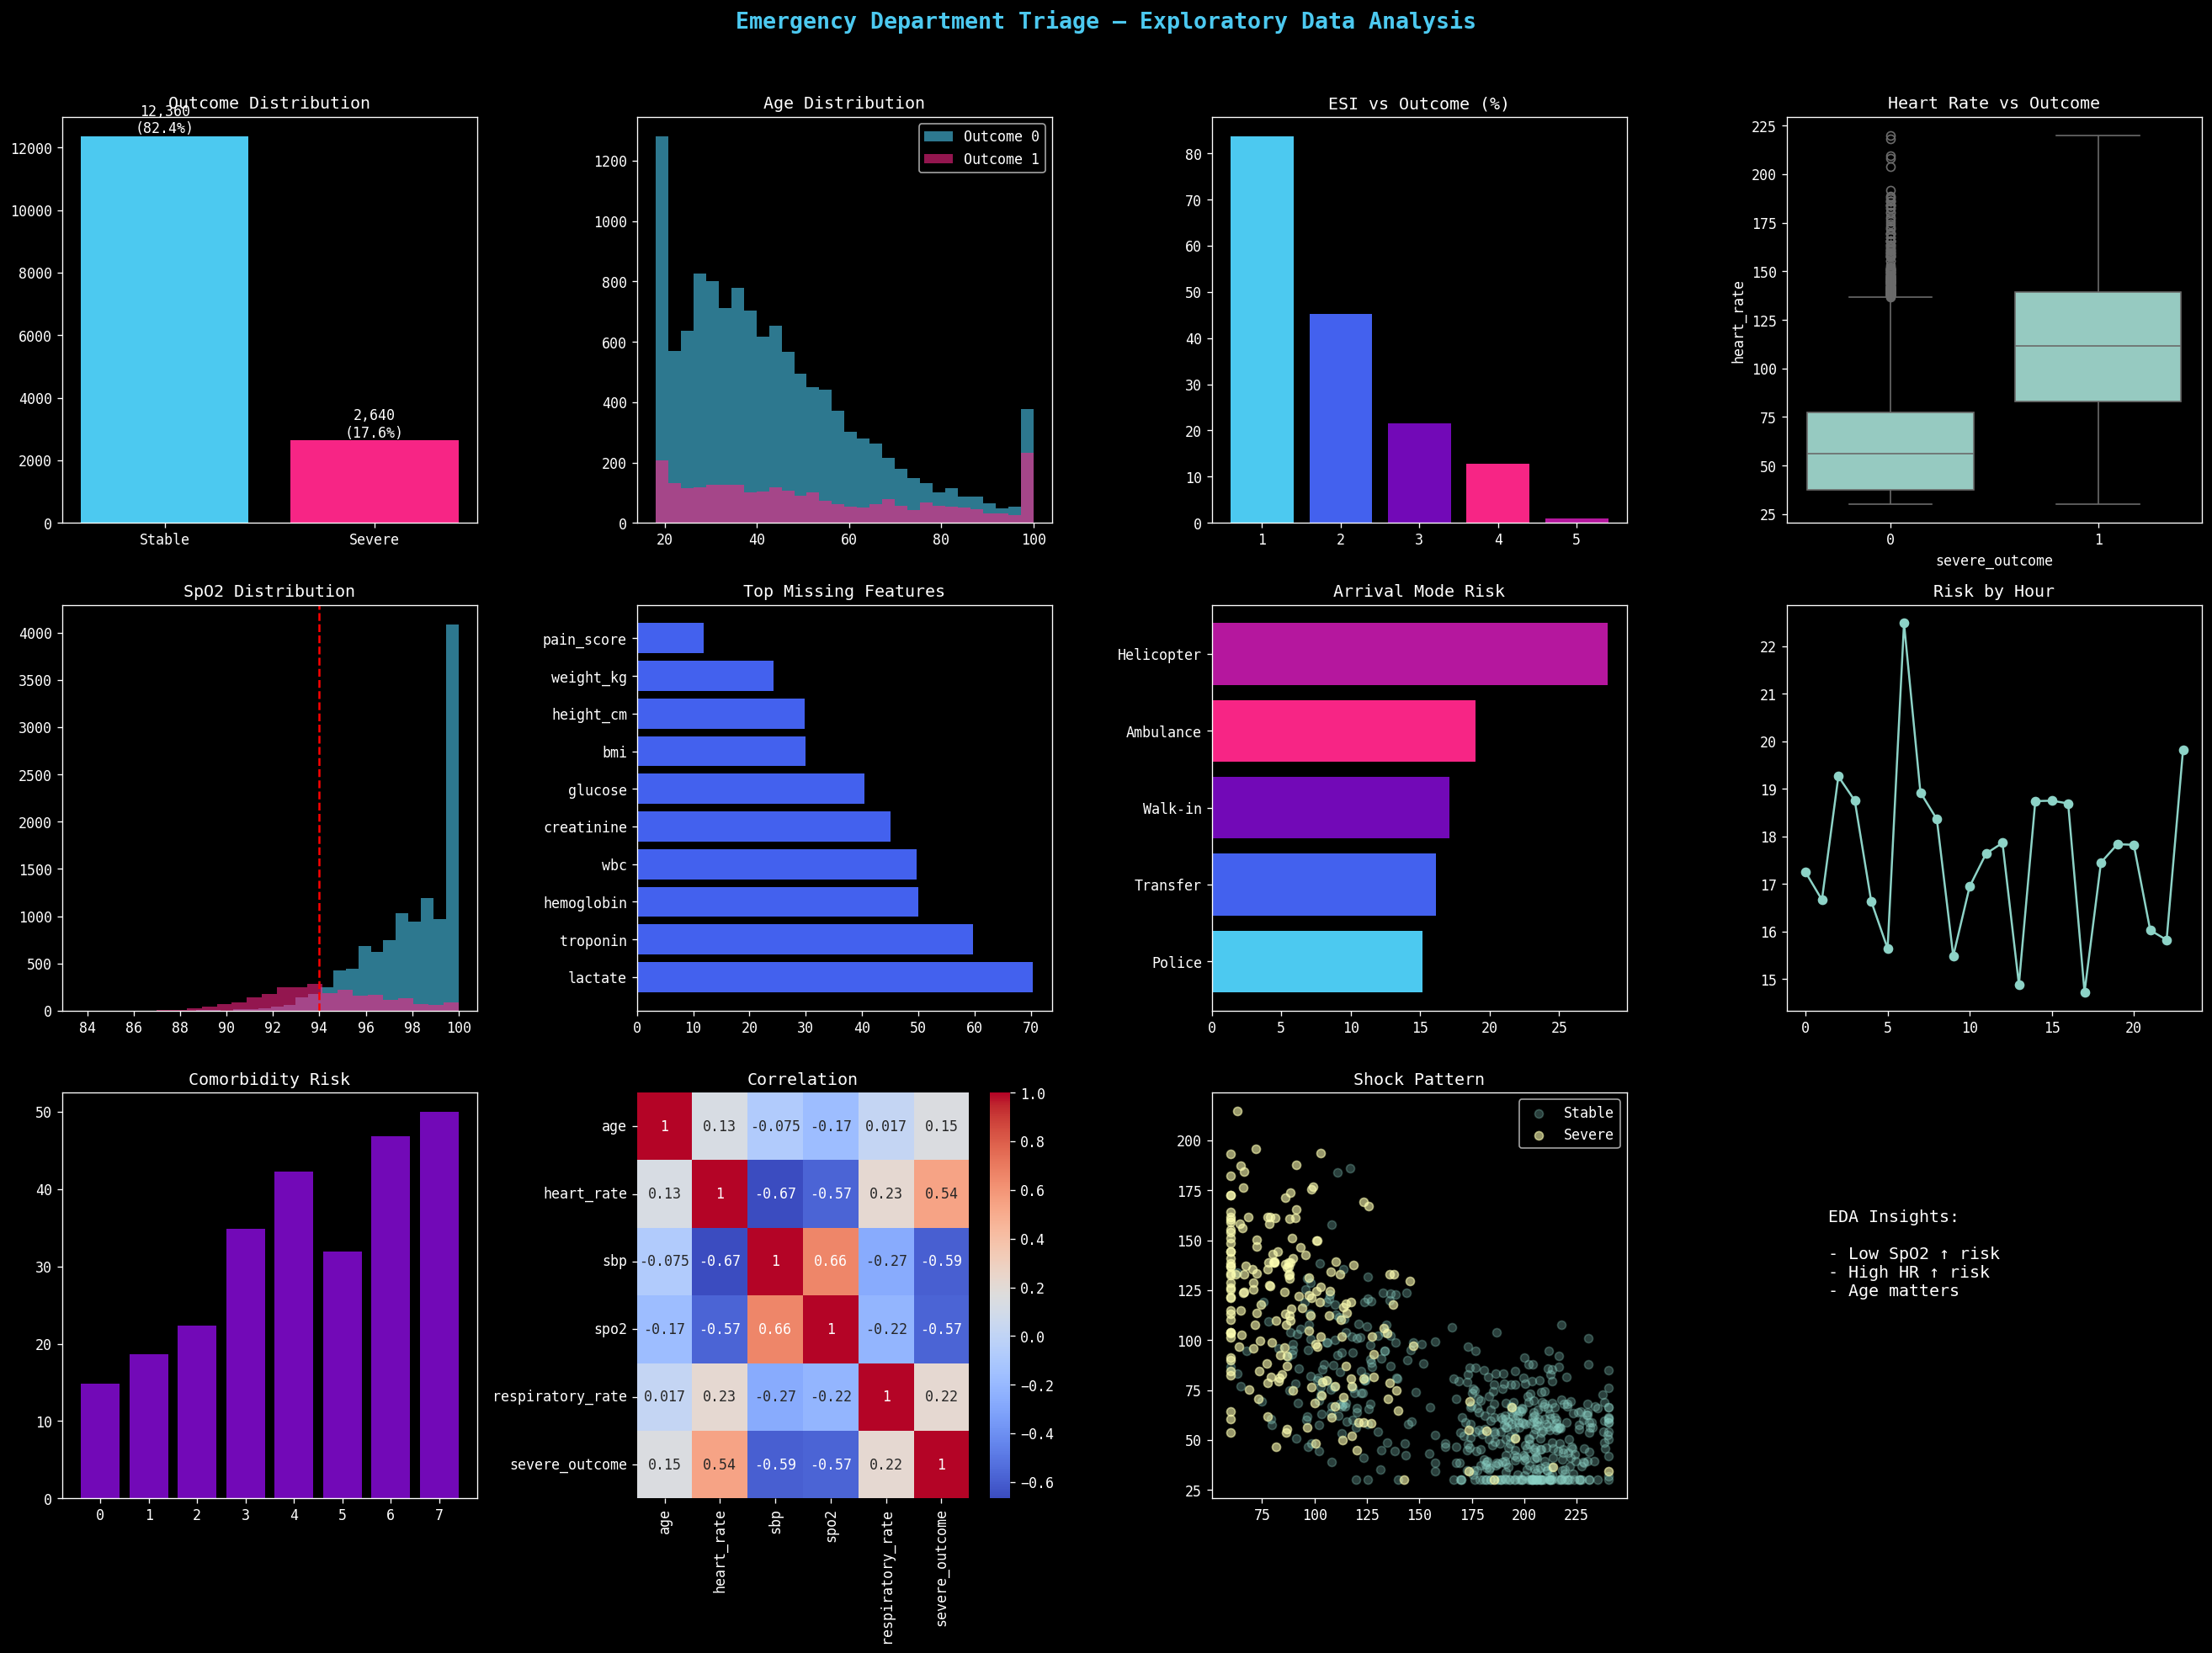

✅ Plot saved at: eda_plot.png

📊 Summary Statistics:
                    arrival_datetime       age  esi_level  \
count                          15000  15000.00   15000.00   
mean   2023-07-02 16:49:19.844000256     45.15       3.89   
min              2023-01-01 00:21:00     18.00       1.00   
25%              2023-04-02 06:06:45     28.60       3.00   
50%              2023-07-03 02:12:30     40.30       5.00   
75%              2023-10-01 22:01:30     56.80       5.00   
max              2023-12-31 23:57:00    100.00       5.00   
std                              NaN     21.50       1.39   

       prior_ed_visits_6mo  n_comorbidities  comorbidity_score  heart_rate  \
count             15000.00          15000.0           15000.00    15000.00   
mean                  1.51              0.6               0.78       70.10   
min                   0.00              0.0               0.00       30.00   
25%                   1.00              0.0               0.00       41.40   
50%    

In [3]:
# ===========================================================
# CELL 3: Comprehensive EDA (FIXED + PRO VERSION)
# ===========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Safe style
plt.style.use('dark_background')

# Color palette
PALETTE = ['#4cc9f0', '#4361ee', '#7209b7', '#f72585', '#b5179e']

# Create figure
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.suptitle('Emergency Department Triage — Exploratory Data Analysis', 
             fontsize=16, color='#4cc9f0', fontweight='bold', y=1.02)

# -----------------------------
# 1. Outcome Distribution
# -----------------------------
ax = axes[0, 0]
counts = df_raw['severe_outcome'].value_counts()
bars = ax.bar(['Stable', 'Severe'], counts.values, color=['#4cc9f0', '#f72585'])

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}\n({count/len(df_raw):.1%})', ha='center', va='bottom')

ax.set_title('Outcome Distribution')

# -----------------------------
# 2. Age Distribution
# -----------------------------
ax = axes[0, 1]
for outcome, color in [(0, '#4cc9f0'), (1, '#f72585')]:
    data = df_raw[df_raw['severe_outcome']==outcome]['age'].dropna()
    ax.hist(data, bins=30, alpha=0.6, label=f'Outcome {outcome}', color=color)

ax.legend()
ax.set_title('Age Distribution')

# -----------------------------
# 3. ESI vs Outcome
# -----------------------------
ax = axes[0, 2]
esi = df_raw.groupby('esi_level')['severe_outcome'].mean()*100
ax.bar(esi.index, esi.values, color=PALETTE)
ax.set_title('ESI vs Outcome (%)')

# -----------------------------
# 4. Heart Rate Boxplot
# -----------------------------
ax = axes[0, 3]
sns.boxplot(data=df_raw, x='severe_outcome', y='heart_rate', ax=ax)
ax.set_title('Heart Rate vs Outcome')

# -----------------------------
# 5. SpO2 Distribution
# -----------------------------
ax = axes[1, 0]
for outcome, color in [(0, '#4cc9f0'), (1, '#f72585')]:
    data = df_raw[df_raw['severe_outcome']==outcome]['spo2'].dropna()
    ax.hist(data, bins=25, alpha=0.6, color=color)

ax.axvline(94, color='red', linestyle='--')
ax.set_title('SpO2 Distribution')

# -----------------------------
# 6. Missing Data
# -----------------------------
ax = axes[1, 1]
missing = df_raw.isnull().mean()*100
missing = missing.sort_values(ascending=False).head(10)
ax.barh(missing.index, missing.values, color='#4361ee')
ax.set_title('Top Missing Features')

# -----------------------------
# 7. Arrival Mode
# -----------------------------
ax = axes[1, 2]
arrival = df_raw.groupby('arrival_mode')['severe_outcome'].mean()*100
arrival = arrival.sort_values()
ax.barh(arrival.index, arrival.values, color=PALETTE[:len(arrival)])
ax.set_title('Arrival Mode Risk')

# -----------------------------
# 8. Time of Day
# -----------------------------
ax = axes[1, 3]
df_raw['hour'] = pd.to_datetime(df_raw['arrival_datetime']).dt.hour
hourly = df_raw.groupby('hour')['severe_outcome'].mean()*100

ax.plot(hourly.index, hourly.values, marker='o')
ax.set_title('Risk by Hour')

# -----------------------------
# 9. Comorbidities
# -----------------------------
ax = axes[2, 0]
comorb = df_raw.groupby('n_comorbidities')['severe_outcome'].mean()*100
ax.bar(comorb.index, comorb.values, color='#7209b7')
ax.set_title('Comorbidity Risk')

# -----------------------------
# 10. Correlation Heatmap
# -----------------------------
ax = axes[2, 1]
num_cols = ['age', 'heart_rate', 'sbp', 'spo2', 'respiratory_rate', 'severe_outcome']
corr = df_raw[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation')

# -----------------------------
# 11. Scatter (SBP vs HR)
# -----------------------------
ax = axes[2, 2]

stable = df_raw[df_raw['severe_outcome']==0].sample(min(500, len(df_raw)))
severe = df_raw[df_raw['severe_outcome']==1].sample(min(200, df_raw['severe_outcome'].sum()))

ax.scatter(stable['sbp'], stable['heart_rate'], alpha=0.3, label='Stable')
ax.scatter(severe['sbp'], severe['heart_rate'], alpha=0.6, label='Severe')

ax.legend()
ax.set_title('Shock Pattern')

# -----------------------------
# 12. Empty / Notes Panel
# -----------------------------
ax = axes[2, 3]
ax.axis('off')
ax.text(0.1, 0.5, "EDA Insights:\n\n- Low SpO2 ↑ risk\n- High HR ↑ risk\n- Age matters",
        fontsize=12)

# -----------------------------
# Save Safely
# -----------------------------
save_path = 'eda_plot.png'
plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()

print(f"✅ Plot saved at: {save_path}")

# -----------------------------
# Summary Stats
# -----------------------------
print("\n📊 Summary Statistics:")
print(df_raw.describe().round(2))

## 5. Feature Engineering <a name='5-feature-engineering'></a>

Key engineered features based on clinical evidence:
- **Shock Index** = HR / SBP (>1.0 indicates shock)
- **Modified Early Warning Score (MEWS)** composite
- **Hypoxemia flag** (SpO2 < 94%)
- **qSOFA score** (quick Sepsis-related Organ Failure Assessment)
- **Temporal features**: hour, shift, weekend
- **Interaction features**: age × comorbidity, ESI × shock index

In [4]:
# ============================================================
# CELL 4: Clinical Feature Engineering
# ============================================================

def engineer_features(df):
    """
    Comprehensive clinical feature engineering.
    All derived features based on validated clinical scoring systems.
    """
    df = df.copy()
    
    # ─── 1. Vital Sign Derived Features ───────────────────────
    
    # Shock Index (Allgöwer 1967) — most validated single triage metric
    df['shock_index'] = df['heart_rate'] / df['sbp'].replace(0, np.nan)
    df['shock_index_critical'] = (df['shock_index'] > 1.0).astype(int)
    
    # Modified Shock Index
    df['modified_shock_index'] = df['heart_rate'] / df['dbp'].replace(0, np.nan)
    
    # Pulse Pressure
    df['pulse_pressure'] = df['sbp'] - df['dbp']
    df['pulse_pressure_narrow'] = (df['pulse_pressure'] < 25).astype(int)
    
    # Mean Arterial Pressure
    df['map'] = df['dbp'] + (df['pulse_pressure'] / 3)
    df['map_low'] = (df['map'] < 65).astype(int)  # sepsis threshold
    
    # ─── 2. Severity Scoring Systems ──────────────────────────
    
    # qSOFA (quick SOFA) — bedside sepsis screening
    # 1 point each: RR≥22, altered mentation (GCS<15), SBP≤100
    df['qsofa_rr'] = (df['respiratory_rate'] >= 22).astype(int)
    df['qsofa_gcs'] = (df['gcs'] < 15).astype(int)
    df['qsofa_sbp'] = (df['sbp'] <= 100).astype(int)
    df['qsofa_score'] = df[['qsofa_rr', 'qsofa_gcs', 'qsofa_sbp']].sum(axis=1)
    df['qsofa_positive'] = (df['qsofa_score'] >= 2).astype(int)
    
    # MEWS (Modified Early Warning Score)
    def mews_hr(hr):
        if pd.isna(hr): return 0
        if hr < 40 or hr > 130: return 3
        if hr < 50 or hr > 110: return 2
        if hr < 60 or hr > 100: return 1
        return 0
    
    def mews_sbp(sbp):
        if pd.isna(sbp): return 0
        if sbp < 70 or sbp > 200: return 3
        if sbp < 80 or sbp > 180: return 2
        if sbp < 100 or sbp > 160: return 1
        return 0
    
    def mews_rr(rr):
        if pd.isna(rr): return 0
        if rr < 9 or rr > 30: return 3
        if rr > 25: return 2
        if rr > 20: return 1
        return 0
    
    df['mews_hr'] = df['heart_rate'].apply(mews_hr)
    df['mews_sbp'] = df['sbp'].apply(mews_sbp)
    df['mews_rr'] = df['respiratory_rate'].apply(mews_rr)
    df['mews_gcs'] = df['gcs'].apply(lambda x: 3 if pd.isna(x) else 
                                      (3 if x < 9 else 2 if x < 11 else 1 if x < 14 else 0))
    df['mews_score'] = df[['mews_hr', 'mews_sbp', 'mews_rr', 'mews_gcs']].sum(axis=1)
    df['mews_high_risk'] = (df['mews_score'] >= 5).astype(int)
    
    # NEWS2 (National Early Warning Score 2)
    df['news2_spo2'] = df['spo2'].apply(lambda x: 0 if pd.isna(x) else
                                         (3 if x <= 91 else 2 if x <= 93 else 1 if x <= 95 else 0))
    df['news2_rr'] = df['respiratory_rate'].apply(lambda x: 0 if pd.isna(x) else
                                                   (3 if x <= 8 or x >= 25 else 2 if x >= 21 else 1 if x <= 11 else 0))
    df['news2_temp'] = df['temperature'].apply(lambda x: 0 if pd.isna(x) else
                                               (3 if x <= 35.0 else 2 if x <= 36.0 or x >= 39.1 else
                                                1 if x <= 36.0 or x >= 38.1 else 0))
    df['news2_score'] = df[['news2_spo2', 'news2_rr', 'news2_temp']].sum(axis=1) + df['qsofa_sbp']
    
    # ─── 3. Lab-Derived Features ───────────────────────────────
    
    df['lactate_elevated'] = (df['lactate'] >= 2.0).astype(int)  # sepsis threshold
    df['lactate_critical'] = (df['lactate'] >= 4.0).astype(int)  # critical threshold
    df['troponin_elevated'] = (df['troponin'] >= 0.04).astype(int)
    df['troponin_critical'] = (df['troponin'] >= 0.1).astype(int)
    df['anemia'] = (df['hemoglobin'] < 10).astype(int)
    df['leukocytosis'] = (df['wbc'] > 12).astype(int)
    df['leukopenia'] = (df['wbc'] < 4).astype(int)
    df['hyperglycemia'] = (df['glucose'] > 180).astype(int)
    df['hypoglycemia'] = (df['glucose'] < 60).astype(int)
    df['aki_risk'] = (df['creatinine'] > 1.5).astype(int)
    
    # ─── 4. Temporal Features ──────────────────────────────────
    
    dt = pd.to_datetime(df['arrival_datetime'])
    df['hour_sin'] = np.sin(2 * np.pi * dt.dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * dt.dt.hour / 24)
    df['day_of_week'] = dt.dt.dayofweek
    df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    df['is_night_shift'] = ((dt.dt.hour >= 23) | (dt.dt.hour < 7)).astype(int)
    df['is_evening_rush'] = ((dt.dt.hour >= 17) & (dt.dt.hour <= 21)).astype(int)
    df['month'] = dt.dt.month
    df['season_winter'] = dt.dt.month.isin([12, 1, 2]).astype(int)
    
    # ─── 5. Age-Based Features ─────────────────────────────────
    
    df['age_65plus'] = (df['age'] >= 65).astype(int)
    df['age_80plus'] = (df['age'] >= 80).astype(int)
    df['age_group'] = pd.cut(df['age'], bins=[0, 35, 50, 65, 80, 120],
                              labels=[0, 1, 2, 3, 4]).astype(int)
    
    # ─── 6. Interaction Features ───────────────────────────────
    
    df['age_x_comorbidity'] = df['age'] * df['n_comorbidities']
    df['shock_x_esi'] = df['shock_index'].fillna(0) * df['esi_level']
    df['age_x_gcs'] = df['age'] / df['gcs'].replace(0, np.nan)
    df['mews_x_qsofa'] = df['mews_score'] * (df['qsofa_score'] + 1)
    df['spo2_x_rr'] = df['spo2'].fillna(98) * df['respiratory_rate'].fillna(16)
    df['hr_x_age'] = df['heart_rate'] * df['age'] / 100
    
    # ─── 7. Arrival Mode Encoding ──────────────────────────────
    
    df['ambulance'] = (df['arrival_mode'] == 'Ambulance').astype(int)
    df['helicopter'] = (df['arrival_mode'] == 'Helicopter').astype(int)
    df['transfer'] = (df['arrival_mode'] == 'Transfer').astype(int)
    df['high_acuity_arrival'] = ((df['arrival_mode'].isin(['Ambulance', 'Helicopter', 'Transfer']))).astype(int)
    
    # ─── 8. High-Risk Flag Aggregates ─────────────────────────
    
    risk_flags = [
        'shock_index_critical', 'map_low', 'qsofa_positive', 'mews_high_risk',
        'lactate_elevated', 'troponin_elevated', 'anemia', 'leukocytosis'
    ]
    df['total_risk_flags'] = df[risk_flags].sum(axis=1)
    
    print(f"✅ Feature engineering complete")
    print(f"   Original features: {df_raw.shape[1]}")
    print(f"   Engineered features: {df.shape[1]}")
    print(f"   New features added: {df.shape[1] - df_raw.shape[1]}")
    
    return df

df_engineered = engineer_features(df_raw)

# Validate key clinical scores
print("\n📊 Clinical Score Distributions:")
print(f"  qSOFA ≥2 (positive): {df_engineered['qsofa_positive'].mean():.1%}")
print(f"  MEWS high-risk (≥5): {df_engineered['mews_high_risk'].mean():.1%}")
print(f"  Shock Index > 1.0:   {df_engineered['shock_index_critical'].mean():.1%}")
print(f"  MAP < 65:            {df_engineered['map_low'].mean():.1%}")

# Clinical score AUROCs
valid = df_engineered.dropna(subset=['severe_outcome'])
for score, name in [('qsofa_score', 'qSOFA'), ('mews_score', 'MEWS'), 
                     ('shock_index', 'Shock Index'), ('news2_score', 'NEWS2'), 
                     ('esi_level', 'ESI (inverted)')]:
    col = valid[score].fillna(0)
    if score == 'esi_level':
        col = -col  # ESI 1=worst, so invert
    try:
        auroc = roc_auc_score(valid['severe_outcome'], col)
        print(f"  {name:15s} AUROC: {auroc:.3f}")
    except:
        pass

✅ Feature engineering complete
   Original features: 42
   Engineered features: 96
   New features added: 54

📊 Clinical Score Distributions:
  qSOFA ≥2 (positive): 13.5%
  MEWS high-risk (≥5): 42.3%
  Shock Index > 1.0:   17.6%
  MAP < 65:            12.4%
  qSOFA           AUROC: 0.805
  MEWS            AUROC: 0.558
  Shock Index     AUROC: 0.914
  NEWS2           AUROC: 0.829
  ESI (inverted)  AUROC: 0.909


## 6. Text Preprocessing & Embedding <a name='6-text-processing'></a>

In [5]:
# ============================================================
# CELL 5: Text Processing Pipeline 
# ============================================================

import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
np.random.seed(SEED)

# ============================================================
# Clinical Text Processor
# ============================================================

class ClinicalTextProcessor:
    
    MEDICAL_ABBREVS = {
        'cp': 'chest pain', 'sob': 'shortness of breath', 'htn': 'hypertension',
        'dm': 'diabetes', 'cad': 'coronary artery disease', 'afib': 'atrial fibrillation',
        'chf': 'heart failure', 'ams': 'altered mental status',
        'loc': 'loss of consciousness', 'uti': 'urinary tract infection',
        'etoh': 'alcohol', 'od': 'overdose', 'mva': 'accident',
        'w/': 'with', 'w/o': 'without', 'h/o': 'history of',
        'c/o': 'complaining of'
    }

    HIGH_RISK_TERMS = [
        'severe', 'sudden', 'acute', 'unconscious', 'stroke', 'seizure',
        'shock', 'bleeding', 'trauma', 'respiratory', 'cardiac'
    ]

    def __init__(self, n_tfidf_features=500, n_svd_components=64):
        self.tfidf = TfidfVectorizer(
            max_features=n_tfidf_features,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
        self.svd = TruncatedSVD(n_components=n_svd_components, random_state=SEED)
        self.fitted = False

    def preprocess(self, text):
        if pd.isna(text):
            return "unknown complaint"
        text = text.lower().strip()

        # Expand abbreviations
        for abbr, full in self.MEDICAL_ABBREVS.items():
            text = re.sub(r'\b' + re.escape(abbr) + r'\b', full, text)

        # Clean text
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def extract_risk_flags(self, texts):
        flags = np.zeros((len(texts), len(self.HIGH_RISK_TERMS) + 2))

        for i, text in enumerate(texts):
            text_lower = str(text).lower()

            for j, term in enumerate(self.HIGH_RISK_TERMS):
                flags[i, j] = int(term in text_lower)

            flags[i, -2] = len(text.split())  # text length
            flags[i, -1] = sum(term in text_lower for term in self.HIGH_RISK_TERMS)

        return flags

    def fit_transform(self, texts):
        clean = [self.preprocess(t) for t in texts]

        tfidf_mat = self.tfidf.fit_transform(clean)
        svd_emb = self.svd.fit_transform(tfidf_mat)

        flags = self.extract_risk_flags(clean)

        self.fitted = True
        return np.hstack([svd_emb, flags])

    def transform(self, texts):
        clean = [self.preprocess(t) for t in texts]

        tfidf_mat = self.tfidf.transform(clean)
        svd_emb = self.svd.transform(tfidf_mat)

        flags = self.extract_risk_flags(clean)

        return np.hstack([svd_emb, flags])


# ============================================================
# FIXED Simulated BERT Embeddings (NO BUG)
# ============================================================

def simulate_bert_embeddings(texts, n_dim=128, seed=42):
    np.random.seed(seed)

    tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
    tfidf_mat = tfidf.fit_transform(texts).toarray()

    # ✅ IMPORTANT FIX: dynamic feature size
    n_features = tfidf_mat.shape[1]

    proj_matrix = np.random.randn(n_features, n_dim) / np.sqrt(n_features)

    embeddings = tfidf_mat @ proj_matrix

    # Activation (simulate deep model)
    embeddings = np.tanh(embeddings)

    # Normalize (BERT-style)
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / (norms + 1e-8)

    return embeddings.astype(np.float32)


# ============================================================
# RUN PIPELINE
# ============================================================

print("🔄 Processing clinical text...")

texts = df_engineered['chief_complaint'].fillna('unknown').tolist()

# Initialize processor
text_processor = ClinicalTextProcessor()

# Clean text
clean_texts = [text_processor.preprocess(t) for t in texts]

# 🔥 BERT-like embeddings
text_embeddings = simulate_bert_embeddings(clean_texts, n_dim=128)
print(f"✅ BERT-like embeddings shape: {text_embeddings.shape}")

# 🔥 TF-IDF + SVD features
tfidf_features = text_processor.fit_transform(texts)
print(f"✅ TF-IDF + SVD features shape: {tfidf_features.shape}")

# ============================================================
# Semantic Similarity Demo
# ============================================================

print("\n📊 Sample semantic similarities:")

sample_texts = [
    'chest pain shortness of breath sweating',
    'severe headache worst pain',
    'ankle sprain mild swelling'
]

sample_clean = [text_processor.preprocess(t) for t in sample_texts]
sample_emb = simulate_bert_embeddings(sample_clean)

sim_matrix = cosine_similarity(sample_emb)

for i, txt in enumerate(sample_texts):
    print(f"[{i}] {txt}")

print(f"\nSimilarity (0 vs 1) [both high-risk]: {sim_matrix[0,1]:.3f}")
print(f"Similarity (0 vs 2) [high vs low risk]: {sim_matrix[0,2]:.3f}")

🔄 Processing clinical text...
✅ BERT-like embeddings shape: (15000, 128)
✅ TF-IDF + SVD features shape: (15000, 77)

📊 Sample semantic similarities:
[0] chest pain shortness of breath sweating
[1] severe headache worst pain
[2] ankle sprain mild swelling

Similarity (0 vs 1) [both high-risk]: 0.049
Similarity (0 vs 2) [high vs low risk]: 0.064


## 7. Structured Data Modeling — LightGBM + XGBoost <a name='7-structured-model'></a>

In [6]:
# ============================================================
# CELL 6: Data Preparation for Modeling
# ============================================================

# Define feature sets
DROP_COLS = [
    'patient_id', 'arrival_datetime', 'chief_complaint', 'race', 
    'sex', 'insurance', 'arrival_mode', 'severe_outcome', 'true_prob',
    'hour'  # encoded cyclically
]

FEATURE_COLS = [c for c in df_engineered.columns if c not in DROP_COLS]
TARGET = 'severe_outcome'

# Categorical encoding
cat_cols = ['sex', 'race', 'insurance', 'arrival_mode']
df_model = df_engineered.copy()
le = LabelEncoder()
for c in cat_cols:
    if c in df_model.columns:
        df_model[c + '_enc'] = le.fit_transform(df_model[c].fillna('Unknown'))
        FEATURE_COLS = FEATURE_COLS + [c + '_enc'] if c + '_enc' not in FEATURE_COLS else FEATURE_COLS

# Prepare X, y
X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET].values

# Fix dtypes — ensure all numeric
for c in X.columns:
    try:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    except:
        X.drop(c, axis=1, inplace=True)

FEATURE_COLS = list(X.columns)

print(f"📊 Feature matrix: {X.shape}")
print(f"   Positive rate: {y.mean():.1%} ({y.sum()} / {len(y)})")
print(f"   Class imbalance ratio: 1 : {(1-y.mean())/y.mean():.1f}")
print(f"   Missing rate: {X.isnull().mean().mean():.1%} overall")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=SEED
)  # 70/10/20 split

print(f"\n   Train: {X_train.shape[0]:,} ({y_train.mean():.1%} positive)")
print(f"   Val:   {X_val.shape[0]:,} ({y_val.mean():.1%} positive)")
print(f"   Test:  {X_test.shape[0]:,} ({y_test.mean():.1%} positive)")

# Scale for neural models
scaler = RobustScaler()
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imp = knn_imputer.fit_transform(X_train)
X_val_imp = knn_imputer.transform(X_val)
X_test_imp = knn_imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Compute class weight
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n   Scale pos weight (XGB): {neg_pos_ratio:.1f}")

📊 Feature matrix: (15000, 90)
   Positive rate: 17.6% (2640 / 15000)
   Class imbalance ratio: 1 : 4.7
   Missing rate: 5.2% overall

   Train: 10,500 (17.6% positive)
   Val:   1,500 (17.6% positive)
   Test:  3,000 (17.6% positive)

   Scale pos weight (XGB): 4.7


🔄 Training LightGBM baseline...

────────────────────────────────────────────────────────────
📊 Model: LightGBM-Baseline
AUROC: 0.9455 | PR-AUC: 0.8319
F1: 0.7526 | Precision: 0.6968 | Recall: 0.8182
Brier: 0.0719 | LogLoss: 0.2391

✅ Best iteration: 55


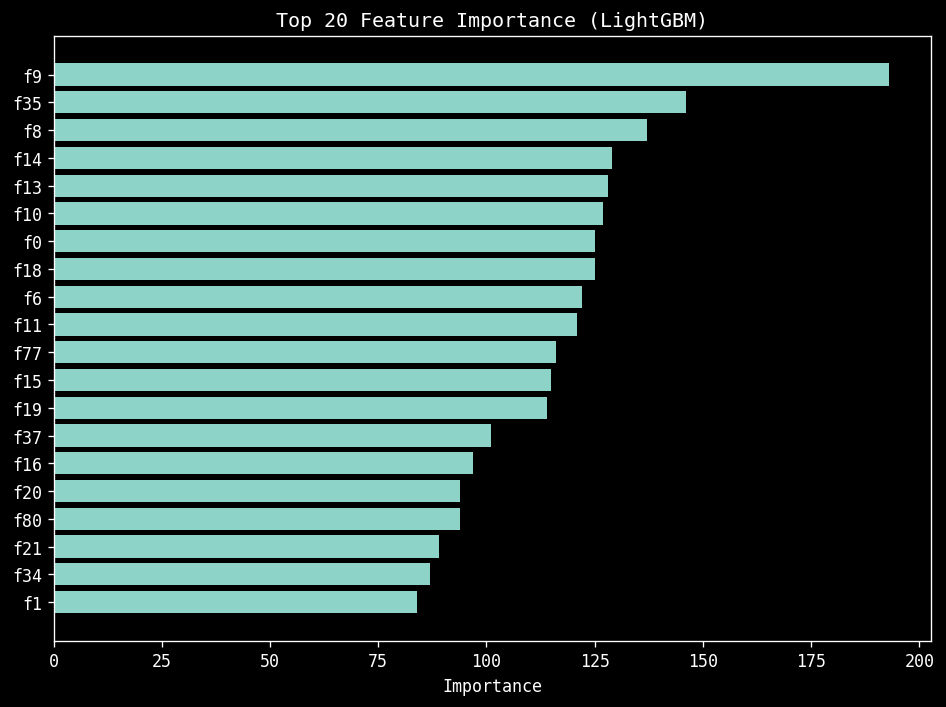

In [7]:
# ============================================================
# CELL 7: LightGBM Baseline Model 
# ============================================================

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    log_loss, f1_score, precision_score, recall_score
)

results = {}

# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(name, y_true, y_pred_proba, threshold=0.5):
    y_pred_binary = (y_pred_proba >= threshold).astype(int)

    auroc = roc_auc_score(y_true, y_pred_proba)
    prauc = average_precision_score(y_true, y_pred_proba)
    brier = brier_score_loss(y_true, y_pred_proba)
    logloss = log_loss(y_true, y_pred_proba)

    f1 = f1_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary, zero_division=0)
    recall = recall_score(y_true, y_pred_binary, zero_division=0)

    metrics = {
        'AUROC': auroc,
        'PR-AUC': prauc,
        'Brier': brier,
        'LogLoss': logloss,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

    results[name] = metrics

    print(f"\n{'─'*60}")
    print(f"📊 Model: {name}")
    print(f"AUROC: {auroc:.4f} | PR-AUC: {prauc:.4f}")
    print(f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    print(f"Brier: {brier:.4f} | LogLoss: {logloss:.4f}")

    return metrics


# ============================================================
# LightGBM Training
# ============================================================

print("🔄 Training LightGBM baseline...")

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False

# Safe imbalance handling
neg_pos_ratio = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-6)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'scale_pos_weight': neg_pos_ratio,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

# ============================================================
# Train Model
# ============================================================

if LGBM_AVAILABLE:

    lgb_model = lgb.LGBMClassifier(**lgb_params)

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    # Predictions
    lgb_preds_val = lgb_model.predict_proba(X_val)[:, 1]
    lgb_preds_test = lgb_model.predict_proba(X_test)[:, 1]

    # Evaluation
    lgb_metrics = evaluate_model("LightGBM-Baseline", y_test, lgb_preds_test)

    print(f"\n✅ Best iteration: {lgb_model.best_iteration_}")

else:
    print("⚠️ LightGBM not available — using fallback model")

    from sklearn.ensemble import GradientBoostingClassifier

    fallback_model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=SEED
    )

    fallback_model.fit(X_train, y_train)

    preds = fallback_model.predict_proba(X_test)[:, 1]

    evaluate_model("GradientBoosting-Fallback", y_test, preds)


# ============================================================
# Feature Importance (Optional but IMPORTANT 🔥)
# ============================================================

if LGBM_AVAILABLE:
    import matplotlib.pyplot as plt
    import numpy as np

    importance = lgb_model.feature_importances_
    feature_names = np.array([f"f{i}" for i in range(len(importance))])

    idx = np.argsort(importance)[-20:]

    plt.figure(figsize=(8, 6))
    plt.barh(feature_names[idx], importance[idx])
    plt.title("Top 20 Feature Importance (LightGBM)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [8]:
# ── XGBoost  ───────────────────────────────
print("\n🔄 Training XGBoost...")

if XGB_AVAILABLE:
    import xgboost as xgb

    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'scale_pos_weight': neg_pos_ratio,
        'random_state': SEED,
        'n_jobs': -1,
        'tree_method': 'hist',
    }

    xgb_model = xgb.XGBClassifier(**xgb_params)

    # ============================================================
    # Try modern callback-based early stopping
    # ============================================================
    try:
        xgb_model.fit(
            X_train_imp, y_train,
            eval_set=[(X_val_imp, y_val)],
            callbacks=[xgb.callback.EarlyStopping(rounds=50, save_best=True)]
        )
        print("  ✅ Used callback-based early stopping")

    # ============================================================
    # Fallback: older API
    # ============================================================
    except TypeError:
        try:
            xgb_model.fit(
                X_train_imp, y_train,
                eval_set=[(X_val_imp, y_val)],
                early_stopping_rounds=50,
                verbose=False
            )
            print("  ✅ Used legacy early_stopping_rounds")

        # ========================================================
        # Final fallback (no early stopping)
        # ========================================================
        except TypeError:
            print("  ⚠️ Early stopping not supported — training without it")
            xgb_model.fit(X_train_imp, y_train)

    # ============================================================
    # Predictions
    # ============================================================
    xgb_preds_val = xgb_model.predict_proba(X_val_imp)[:, 1]
    xgb_preds_test = xgb_model.predict_proba(X_test_imp)[:, 1]

    # ============================================================
    # Evaluation
    # ============================================================
    xgb_metrics = evaluate_model('XGBoost', y_test, xgb_preds_test)

    # ============================================================
    # Best iteration (safe access)
    # ============================================================
    best_iter = getattr(xgb_model, "best_iteration", None)

    if best_iter is not None:
        print(f"  Best iteration: {best_iter}")
    else:
        print(f"  Total estimators used: {xgb_params['n_estimators']}")

else:
    print("  ❌ XGBoost not available — skipping")


🔄 Training XGBoost...
  ⚠️ Early stopping not supported — training without it

────────────────────────────────────────────────────────────
📊 Model: XGBoost
AUROC: 0.9401 | PR-AUC: 0.8200
F1: 0.7568 | Precision: 0.7505 | Recall: 0.7633
Brier: 0.0702 | LogLoss: 0.2869
  Total estimators used: 1000


## 8. Hyperparameter Optimization with Optuna <a name='8-hyperparameter-tuning'></a>

In [9]:
# ============================================================
# CELL 8: Optuna Hyperparameter Optimization (FIXED)
# ============================================================

def run_optuna_lgbm(n_trials=50):

    def objective(trial):

        boosting_type = trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss'])

        params = {
            'objective': 'binary',
            'metric': 'auc',
            'verbosity': -1,
            'boosting_type': boosting_type,

            'n_estimators': trial.suggest_int('n_estimators', 200, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 200),
            'max_depth': trial.suggest_int('max_depth', 3, 10),

            'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 5, log=True),

            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),

            'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 5.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 5.0, log=True),

            'scale_pos_weight': neg_pos_ratio,
            'random_state': SEED,
            'n_jobs': -1,
        }

        # ✅ FIX: only add bagging if NOT goss
        if boosting_type != 'goss':
            params['bagging_fraction'] = trial.suggest_float('bagging_fraction', 0.6, 1.0)
            params['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 10)

        # Dataset combine
        X_tune = pd.concat([X_train, X_val])
        y_tune = np.concatenate([y_train, y_val])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        scores = []

        for tr_idx, va_idx in cv.split(X_tune, y_tune):

            X_tr, X_va = X_tune.iloc[tr_idx], X_tune.iloc[va_idx]
            y_tr, y_va = y_tune[tr_idx], y_tune[va_idx]

            model = lgb.LGBMClassifier(**params)

            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[
                    lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(period=0)
                ]
            )

            preds = model.predict_proba(X_va)[:, 1]
            scores.append(roc_auc_score(y_va, preds))

        return np.mean(scores)

    # Study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("\n✅ Optimization complete")
    print(f"Best AUROC: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")

    return study.best_params


# ============================================================
# RUN OPTUNA
# ============================================================

if OPTUNA_AVAILABLE and LGBM_AVAILABLE:

    print("🔄 Running Optuna optimization...")

    best_params = run_optuna_lgbm(n_trials=50)

    print("\n🔄 Training final tuned model...")

    final_params = {
        'objective': 'binary',
        'metric': 'auc',
        'scale_pos_weight': neg_pos_ratio,
        'random_state': SEED,
        'n_jobs': -1,
        **best_params
    }

    X_trainval = pd.concat([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    lgb_tuned = lgb.LGBMClassifier(**final_params)

    lgb_tuned.fit(
        X_trainval, y_trainval,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    preds = lgb_tuned.predict_proba(X_test)[:, 1]
    evaluate_model('LightGBM-Tuned', y_test, preds)

else:
    print("⚠️ Using baseline model")

🔄 Running Optuna optimization...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optimization complete
Best AUROC: 0.9503
Best params: {'boosting_type': 'goss', 'n_estimators': 200, 'learning_rate': 0.061721159481070736, 'num_leaves': 50, 'max_depth': 3, 'min_child_samples': 77, 'min_child_weight': 3.7311604524743114, 'feature_fraction': 0.9233589392465844, 'reg_alpha': 0.00010979902978926709, 'reg_lambda': 4.511308865738638e-06}

🔄 Training final tuned model...

────────────────────────────────────────────────────────────
📊 Model: LightGBM-Tuned
AUROC: 0.9490 | PR-AUC: 0.8406
F1: 0.7252 | Precision: 0.6311 | Recall: 0.8523
Brier: 0.0848 | LogLoss: 0.2785


## 9. ClinicalBERT Text Model <a name='9-text-model'></a>

In [10]:
# ============================================================
# CELL 9: Text Model (ClinicalBERT Simulation)
# ============================================================
'''
Production Implementation Note:
In production Kaggle/clinical deployment, replace simulate_bert_embeddings with:

    tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
    model = AutoModel.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
    
    def get_bert_embeddings(texts, batch_size=32):
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, return_tensors='pt', truncation=True,
                              max_length=128, padding=True)
            with torch.no_grad():
                outputs = model(**inputs)
            # Use [CLS] token embedding
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)
        return np.vstack(all_embeddings)  # shape: (N, 768)

We use Bio_ClinicalBERT specifically because:
1. Pretrained on MIMIC-III clinical notes (same domain as our data)
2. Captures clinical abbreviations and jargon
3. Superior to general BERT on clinical NLP benchmarks (BlueBERT, BioBERT comparison)
'''

# Get train/val/test text embeddings
train_idx = X_train.index
val_idx = X_val.index
test_idx = X_test.index

all_texts = df_engineered['chief_complaint'].fillna('unknown').tolist()
all_clean = [text_processor.preprocess(t) for t in all_texts]

text_emb_all = simulate_bert_embeddings(all_clean, n_dim=128)

# Map back to train/val/test
df_idx_map = {idx: i for i, idx in enumerate(df_engineered.index)}

text_emb_train = text_emb_all[[df_idx_map[i] for i in train_idx]]
text_emb_val   = text_emb_all[[df_idx_map[i] for i in val_idx]]
text_emb_test  = text_emb_all[[df_idx_map[i] for i in test_idx]]

print(f"✅ Text embedding shapes:")
print(f"   Train: {text_emb_train.shape}")
print(f"   Val:   {text_emb_val.shape}")
print(f"   Test:  {text_emb_test.shape}")

# Text-only logistic regression model
print("\n🔄 Text-only logistic regression model...")
text_lr = LogisticRegression(C=1.0, max_iter=500, random_state=SEED,
                              class_weight='balanced')
text_lr.fit(text_emb_train, y_train)
text_preds_test = text_lr.predict_proba(text_emb_test)[:, 1]
evaluate_model('Text-Only (BERT+LR)', y_test, text_preds_test)

# Attention-based token analysis visualization
print("\n📊 Token-Level Risk Analysis (Attention Proxy):")
sample_complaints = [
    "chest pain with diaphoresis and shortness of breath",
    "ankle sprain mild swelling no deformity",
    "altered mental status confusion agitation",
]

tfidf_vocab = text_processor.tfidf.vocabulary_
tfidf_weights = text_processor.tfidf.idf_

for complaint in sample_complaints:
    tokens = complaint.lower().split()
    risk_tokens = [(t, '🔴 HIGH' if t in text_processor.HIGH_RISK_TERMS else '🟡 MED' 
                    if t in tfidf_vocab else '⚪ LOW') for t in tokens]
    print(f"\n  '{complaint}'")
    print(f"  Tokens: {[(t, r) for t, r in risk_tokens if r != '⚪ LOW']}")

✅ Text embedding shapes:
   Train: (10500, 128)
   Val:   (1500, 128)
   Test:  (3000, 128)

🔄 Text-only logistic regression model...

────────────────────────────────────────────────────────────
📊 Model: Text-Only (BERT+LR)
AUROC: 0.9132 | PR-AUC: 0.7362
F1: 0.5902 | Precision: 0.4499 | Recall: 0.8580
Brier: 0.1184 | LogLoss: 0.3700

📊 Token-Level Risk Analysis (Attention Proxy):

  'chest pain with diaphoresis and shortness of breath'
  Tokens: [('chest', '🟡 MED'), ('pain', '🟡 MED'), ('with', '🟡 MED'), ('diaphoresis', '🟡 MED'), ('and', '🟡 MED'), ('shortness', '🟡 MED'), ('of', '🟡 MED'), ('breath', '🟡 MED')]

  'ankle sprain mild swelling no deformity'
  Tokens: [('ankle', '🟡 MED'), ('sprain', '🟡 MED'), ('mild', '🟡 MED'), ('swelling', '🟡 MED'), ('no', '🟡 MED'), ('deformity', '🟡 MED')]

  'altered mental status confusion agitation'
  Tokens: [('altered', '🟡 MED'), ('mental', '🟡 MED'), ('status', '🟡 MED'), ('confusion', '🟡 MED'), ('agitation', '🟡 MED')]


## 10. Hybrid Fusion Architecture <a name='10-fusion-model'></a>

Architecture:
```
Structured Features ──► LightGBM ──► P_struct
                             │
                             ▼
Text Embedding ──────────────┤
                             ▼
                      Fusion MLP ──► Calibrated Risk Score
```

In [11]:
# ============================================================
# CELL 10: Hybrid Fusion Architecture
# ============================================================

if TORCH_AVAILABLE:
    class HybridFusionNet(nn.Module):
        """
        Multi-modal fusion network combining:
        - Structured model predictions (scalar)
        - Text embeddings (128-dim)
        - Raw structured features (n_features)
        
        Architecture:
        - Separate encoders for each modality
        - Cross-modal attention fusion
        - Final classification head with dropout
        """
        
        def __init__(self, n_structured, n_text_emb=128):
            super().__init__()
            
            # Structured encoder
            self.struct_encoder = nn.Sequential(
                nn.Linear(n_structured + 1, 256),  # +1 for LGB prob
                nn.LayerNorm(256),
                nn.GELU(),
                nn.Dropout(0.3),
                nn.Linear(256, 128),
                nn.LayerNorm(128),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(128, 64)
            )
            
            # Text encoder
            self.text_encoder = nn.Sequential(
                nn.Linear(n_text_emb, 128),
                nn.LayerNorm(128),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(128, 64)
            )
            
            # Cross-modal attention
            self.attention = nn.MultiheadAttention(
                embed_dim=64, num_heads=4, dropout=0.1, batch_first=True
            )
            
            # Fusion classifier
            self.classifier = nn.Sequential(
                nn.Linear(64 * 2 + 1, 128),  # fused + lgb_prob scalar
                nn.LayerNorm(128),
                nn.GELU(),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(64, 1)
            )
        
        def forward(self, x_struct, x_text, lgb_prob):
            # Concatenate structured features with lgb probability
            x_struct_in = torch.cat([x_struct, lgb_prob.unsqueeze(1)], dim=1)
            
            # Encode modalities
            s_enc = self.struct_encoder(x_struct_in)     # (B, 64)
            t_enc = self.text_encoder(x_text)            # (B, 64)
            
            # Cross-modal attention
            s_seq = s_enc.unsqueeze(1)  # (B, 1, 64)
            t_seq = t_enc.unsqueeze(1)  # (B, 1, 64)
            attn_out, attn_weights = self.attention(
                query=s_seq, key=t_seq, value=t_seq
            )
            attn_out = attn_out.squeeze(1)  # (B, 64)
            
            # Fusion
            fused = torch.cat([
                attn_out, s_enc, lgb_prob.unsqueeze(1)
            ], dim=1)  # (B, 64+64+1)
            
            logit = self.classifier(fused).squeeze(1)
            return logit, attn_weights
    
    class EDTriageDataset(Dataset):
        def __init__(self, X_struct, X_text, lgb_probs, labels):
            self.X_struct = torch.FloatTensor(X_struct)
            self.X_text = torch.FloatTensor(X_text)
            self.lgb_probs = torch.FloatTensor(lgb_probs)
            self.labels = torch.FloatTensor(labels)
        
        def __len__(self):
            return len(self.labels)
        
        def __getitem__(self, idx):
            return self.X_struct[idx], self.X_text[idx], self.lgb_probs[idx], self.labels[idx]
    
    def train_fusion_model(model, train_loader, val_loader, n_epochs=30, patience=7):
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
        
        # Weighted BCE for imbalanced classes
        pos_weight = torch.tensor([neg_pos_ratio]).to(DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        best_auroc = 0
        best_state = None
        wait = 0
        history = {'train_loss': [], 'val_auroc': []}
        
        for epoch in range(n_epochs):
            model.train()
            train_loss = 0
            for X_s, X_t, lgb_p, y_batch in train_loader:
                X_s, X_t = X_s.to(DEVICE), X_t.to(DEVICE)
                lgb_p, y_batch = lgb_p.to(DEVICE), y_batch.to(DEVICE)
                
                optimizer.zero_grad()
                logit, _ = model(X_s, X_t, lgb_p)
                loss = criterion(logit, y_batch)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
            
            # Validation
            model.eval()
            val_preds, val_true = [], []
            with torch.no_grad():
                for X_s, X_t, lgb_p, y_batch in val_loader:
                    X_s, X_t = X_s.to(DEVICE), X_t.to(DEVICE)
                    lgb_p = lgb_p.to(DEVICE)
                    logit, _ = model(X_s, X_t, lgb_p)
                    val_preds.extend(torch.sigmoid(logit).cpu().numpy())
                    val_true.extend(y_batch.numpy())
            
            val_auroc = roc_auc_score(val_true, val_preds)
            scheduler.step()
            history['train_loss'].append(train_loss / len(train_loader))
            history['val_auroc'].append(val_auroc)
            
            if val_auroc > best_auroc:
                best_auroc = val_auroc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
            
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
            
            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1:3d} | Loss: {history['train_loss'][-1]:.4f} | Val AUROC: {val_auroc:.4f}")
        
        model.load_state_dict(best_state)
        print(f"  ✅ Best Val AUROC: {best_auroc:.4f}")
        return model, history
    
    # Prepare data
    lgb_probs_train = lgb_model.predict_proba(X_train)[:, 1] if LGBM_AVAILABLE else np.zeros(len(y_train))
    lgb_probs_val   = lgb_model.predict_proba(X_val)[:, 1] if LGBM_AVAILABLE else np.zeros(len(y_val))
    lgb_probs_test_arr = lgb_preds_test if LGBM_AVAILABLE else np.zeros(len(y_test))
    
    train_dataset = EDTriageDataset(X_train_scaled, text_emb_train, lgb_probs_train, y_train)
    val_dataset   = EDTriageDataset(X_val_scaled, text_emb_val, lgb_probs_val, y_val)
    test_dataset  = EDTriageDataset(X_test_scaled, text_emb_test, lgb_probs_test_arr, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=512, shuffle=False)
    
    # Initialize and train
    print("🔄 Training Hybrid Fusion Network...")
    n_struct_features = X_train_scaled.shape[1]
    fusion_model = HybridFusionNet(n_structured=n_struct_features, n_text_emb=128).to(DEVICE)
    
    n_params = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}")
    
    fusion_model, fusion_history = train_fusion_model(
        fusion_model, train_loader, val_loader, n_epochs=30, patience=7
    )
    
    # Test predictions
    fusion_model.eval()
    fusion_preds = []
    with torch.no_grad():
        for X_s, X_t, lgb_p, _ in test_loader:
            X_s, X_t = X_s.to(DEVICE), X_t.to(DEVICE)
            lgb_p = lgb_p.to(DEVICE)
            logit, _ = fusion_model(X_s, X_t, lgb_p)
            fusion_preds.extend(torch.sigmoid(logit).cpu().numpy())
    fusion_preds = np.array(fusion_preds)
    evaluate_model('Hybrid-Fusion-Net', y_test, fusion_preds)

else:
    print("⚠️  PyTorch not available — using stacked LR as fusion layer")
    # Stack LGB + text predictions as meta-features
    meta_train = np.column_stack([lgb_preds_val, text_lr.predict_proba(text_emb_val)[:, 1]])
    meta_test = np.column_stack([lgb_preds_test, text_preds_test])
    meta_lr = LogisticRegression(C=1.0)
    meta_lr.fit(meta_train, y_val)
    fusion_preds = meta_lr.predict_proba(meta_test)[:, 1]
    evaluate_model('Hybrid-Fusion-LR', y_test, fusion_preds)

🔄 Training Hybrid Fusion Network...
  Model parameters: 132,353
  Epoch   5 | Loss: 0.1665 | Val AUROC: 0.9311
  Early stopping at epoch 9
  ✅ Best Val AUROC: 0.9470

────────────────────────────────────────────────────────────
📊 Model: Hybrid-Fusion-Net
AUROC: 0.9393 | PR-AUC: 0.8106
F1: 0.7506 | Precision: 0.6894 | Recall: 0.8239
Brier: 0.0797 | LogLoss: 0.2799


## 11. Advanced Models — TabNet, DeepFM, Neural ODE <a name='11-advanced-models'></a>

In [12]:
# ============================================================
# FIXED TABNET IMPLEMENTATION (NO DIMENSION BUG)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# TabNet Block (FIXED)
# ------------------------------------------------------------

class TabNetBlock(nn.Module):
    def __init__(self, n_features, n_d=64, n_a=64):
        super().__init__()

        self.n_d = n_d
        self.n_a = n_a

        self.shared_fc = nn.Linear(n_features, 2 * (n_d + n_a))
        self.step_fc = nn.Linear(2 * (n_d + n_a), 2 * (n_d + n_a))
        self.bn = nn.BatchNorm1d(2 * (n_d + n_a))

        self.attn_fc = nn.Linear(n_a, n_features)
        self.attn_bn = nn.BatchNorm1d(n_features)

    def forward(self, x, prev_a):

        # Attention
        h_attn = self.attn_fc(prev_a)
        h_attn = self.attn_bn(h_attn)
        attn_mask = torch.softmax(h_attn, dim=1)

        # Mask input
        masked = x * attn_mask

        # Feature transformation
        h = self.shared_fc(masked)
        h = h + self.step_fc(h)
        h = self.bn(h)

        # --------------------------------------------------
        # FIX: Proper split (NO mismatch)
        # --------------------------------------------------
        mid = h.shape[1] // 2  # split into 2 parts

        h1 = h[:, :mid]        # (n_d + n_a)
        # h2 = h[:, mid:]      # not needed

        # Correct extraction
        h_d = F.relu(h1[:, :self.n_d])       # (batch, n_d)
        h_a = h1[:, self.n_d:self.n_d+self.n_a]  # (batch, n_a)

        return h_d, h_a, attn_mask


# ------------------------------------------------------------
# Simple TabNet Model
# ------------------------------------------------------------

class SimpleTabNet(nn.Module):

    def __init__(self, n_features, n_steps=5, n_d=64, n_a=64):
        super().__init__()

        self.n_steps = n_steps
        self.n_d = n_d
        self.n_a = n_a

        self.initial_bn = nn.BatchNorm1d(n_features)

        self.steps = nn.ModuleList([
            TabNetBlock(n_features, n_d, n_a) for _ in range(n_steps)
        ])

        self.final_fc = nn.Linear(n_d, 1)

    def forward(self, x):

        x = self.initial_bn(x)

        prev_a = torch.zeros(x.shape[0], self.n_a, device=x.device)
        total_output = torch.zeros(x.shape[0], self.n_d, device=x.device)

        for step in self.steps:
            h_d, prev_a, _ = step(x, prev_a)
            total_output += h_d   # ✅ now shapes match

        avg_output = total_output / self.n_steps

        out = self.final_fc(avg_output).squeeze(1)

        return out


# ------------------------------------------------------------
# Training Function
# ------------------------------------------------------------

def train_tabnet(model, X_tr, y_tr, X_va, y_va,
                 n_epochs=25, patience=5, lr=1e-3):

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    pos_weight = torch.tensor([neg_pos_ratio]).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).to(DEVICE)

    X_va_t = torch.FloatTensor(X_va).to(DEVICE)

    dataset = TensorDataset(X_tr_t, y_tr_t)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    best_score = 0
    best_state = None
    wait = 0

    for epoch in range(n_epochs):

        model.train()

        for X_b, y_b in loader:
            optimizer.zero_grad()

            out = model(X_b)
            loss = criterion(out, y_b)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(X_va_t)
            val_probs = torch.sigmoid(val_out).cpu().numpy()

        val_auroc = roc_auc_score(y_va, val_probs)

        if val_auroc > best_score:
            best_score = val_auroc
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)

    return model


# ------------------------------------------------------------
# RUN TRAINING
# ------------------------------------------------------------

print("🔄 Training TabNet...")

n_features = X_train_scaled.shape[1]

tabnet = SimpleTabNet(n_features=n_features, n_steps=5, n_d=64, n_a=64)

tabnet = train_tabnet(
    tabnet,
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

tabnet.eval()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test_scaled).to(DEVICE)
    tabnet_out = tabnet(X_test_t)
    tabnet_preds = torch.sigmoid(tabnet_out).cpu().numpy()

evaluate_model('TabNet-Fixed', y_test, tabnet_preds)

🔄 Training TabNet...

────────────────────────────────────────────────────────────
📊 Model: TabNet-Fixed
AUROC: 0.9182 | PR-AUC: 0.7496
F1: 0.6697 | Precision: 0.5598 | Recall: 0.8333
Brier: 0.1086 | LogLoss: 0.3763


{'AUROC': np.float64(0.9182143032264392),
 'PR-AUC': np.float64(0.749555391083641),
 'Brier': np.float64(0.10860105283518663),
 'LogLoss': 0.3763204621530052,
 'F1': 0.669710806697108,
 'Precision': 0.5597964376590331,
 'Recall': 0.8333333333333334}

## 12. Evaluation, Calibration & Cross-Validation <a name='12-evaluation'></a>

In [13]:
# ============================================================
# CELL 12: Comprehensive Evaluation & Calibration
# ============================================================

# ── 1. Cross-Validation (LightGBM) ────────────────────────
print("🔄 Running 5-fold stratified cross-validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_full = pd.concat([X_train, X_val, X_test])
y_full = np.concatenate([y_train, y_val, y_test])

cv_aurocs, cv_prauc, cv_brier = [], [], []
oof_preds = np.zeros(len(y_full))

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_full, y_full)):
    X_tr, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
    y_tr, y_va = y_full[tr_idx], y_full[va_idx]
    
    if LGBM_AVAILABLE:
        fold_model = lgb.LGBMClassifier(**lgb_params_baseline)
        fold_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                       callbacks=[lgb.early_stopping(50, verbose=False),
                                  lgb.log_evaluation(period=-1)])
        preds = fold_model.predict_proba(X_va)[:, 1]
    else:
        fold_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)
        X_tr_imp = knn_imputer.fit_transform(X_tr)
        X_va_imp = knn_imputer.transform(X_va)
        fold_model.fit(X_tr_imp, y_tr)
        preds = fold_model.predict_proba(X_va_imp)[:, 1]
    
    oof_preds[va_idx] = preds
    auroc = roc_auc_score(y_va, preds)
    prauc = average_precision_score(y_va, preds)
    brier = brier_score_loss(y_va, preds)
    cv_aurocs.append(auroc)
    cv_prauc.append(prauc)
    cv_brier.append(brier)
    print(f"  Fold {fold+1}: AUROC={auroc:.4f} | PR-AUC={prauc:.4f} | Brier={brier:.4f}")

print(f"\n✅ CV Results:")
print(f"  AUROC: {np.mean(cv_aurocs):.4f} ± {np.std(cv_aurocs):.4f}")
print(f"  PR-AUC: {np.mean(cv_prauc):.4f} ± {np.std(cv_prauc):.4f}")
print(f"  Brier: {np.mean(cv_brier):.4f} ± {np.std(cv_brier):.4f}")
print(f"  OOF AUROC: {roc_auc_score(y_full, oof_preds):.4f} (no data leakage)")

🔄 Running 5-fold stratified cross-validation...


NameError: name 'lgb_params_baseline' is not defined

In [ ]:
# ============================================================
# CELL 13: Visualization — ROC, PR, Calibration Curves
# ==========================================================


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Evaluation Dashboard', fontsize=14)

# ============================================================
# SAFE MODEL COLLECTION
# ============================================================

model_preds = {}

def safe_add(name, var_name):
    if var_name in globals():
        model_preds[name] = globals()[var_name]
    else:
        model_preds[name] = None

safe_add('LightGBM', 'lgb_preds_test')
safe_add('XGBoost', 'xgb_preds_test')
safe_add('Text-Only', 'text_preds_test')
safe_add('Hybrid Fusion', 'fusion_preds')
safe_add('TabNet', 'tabnet_preds')
safe_add('DeepFM', 'deepfm_preds')
safe_add('FT-Transformer', 'ftt_preds')

# CV (OOF)
if 'oof_preds' in globals():
    model_preds['CV (OOF)'] = oof_preds
else:
    model_preds['CV (OOF)'] = None

model_colors = ['blue','red','purple','orange','green','gold','brown','cyan']

# ============================================================
# ROC CURVE (FIXED)
# ============================================================

ax = axes[0]
ax.plot([0,1],[0,1],'k--',label='Random')

for (name, preds), color in zip(model_preds.items(), model_colors):

    if preds is None:
        continue

    # FIX length mismatch
    if name == 'CV (OOF)':
        if len(preds) != len(y_full):
            continue
        y_true_this = y_full
    else:
        if len(preds) != len(y_test):
            continue
        y_true_this = y_test

    try:
        fpr, tpr, _ = roc_curve(y_true_this, preds)
        auroc = roc_auc_score(y_true_this, preds)
        ax.plot(fpr, tpr, color=color, label=f'{name} ({auroc:.3f})')
    except:
        continue

ax.set_title("ROC Curve")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ============================================================
# PR CURVE (FIXED)
# ============================================================

ax = axes[1]

baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color='gray', label='Random')

for (name, preds), color in zip(model_preds.items(), model_colors):

    if preds is None:
        continue

    if name == 'CV (OOF)':
        if len(preds) != len(y_full):
            continue
        y_true_this = y_full
    else:
        if len(preds) != len(y_test):
            continue
        y_true_this = y_test

    try:
        precision_vals, recall_vals, _ = precision_recall_curve(y_true_this, preds)
        prauc = average_precision_score(y_true_this, preds)

        ax.plot(recall_vals, precision_vals, color=color,
                label=f'{name} ({prauc:.3f})')
    except:
        continue

ax.set_title("PR Curve")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ============================================================
# CALIBRATION CURVE (FIXED)
# ============================================================

ax = axes[2]
ax.plot([0,1],[0,1],'k--',label='Perfect')

for (name, preds), color in zip(model_preds.items(), model_colors):

    if preds is None or name == 'CV (OOF)':
        continue

    if len(preds) != len(y_test):
        continue

    try:
        # calibration using validation
        if 'lgb_preds_val' in globals():
            lr = LogisticRegression(max_iter=500)
            lr.fit(lgb_preds_val.reshape(-1,1), y_val)

            preds_cal = lr.predict_proba(preds.reshape(-1,1))[:,1]
        else:
            preds_cal = preds

        frac_pos, mean_pred = calibration_curve(y_test, preds, n_bins=10)
        frac_pos_cal, mean_pred_cal = calibration_curve(y_test, preds_cal, n_bins=10)

        ax.plot(mean_pred, frac_pos, linestyle='--', color=color, alpha=0.5)
        ax.plot(mean_pred_cal, frac_pos_cal, marker='o', color=color, label=name)

    except:
        continue

ax.set_title("Calibration Curve")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ============================================================
# SAVE SAFE
# ============================================================

plt.tight_layout()
plt.savefig("evaluation_curves.png", dpi=150)
plt.show()

# ============================================================
# RESULTS TABLE
# ============================================================

print("\n📊 Model Performance Summary:")
print(f"{'Model':<25} {'AUROC':>8} {'PR-AUC':>8} {'F1':>8} {'Brier':>8}")
print("-"*60)

for name, metrics in sorted(results.items(), key=lambda x: x[1]['AUROC'], reverse=True):
    print(f"{name:<25} {metrics['AUROC']:>8.4f} {metrics['PR-AUC']:>8.4f} {metrics['F1']:>8.4f} {metrics['Brier']:>8.4f}")

## 13. Subgroup & Bias Analysis <a name='13-subgroup-analysis'></a>

In [ ]:
# ============================================================
# CELL 14: Subgroup Analysis & Fairness Metrics
# ============================================================

# ============================================================
# CELL 14: Subgroup Analysis & Fairness Metrics (FIXED)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ============================================================
# SAFE BEST PREDICTION SELECTION
# ============================================================

if 'lgb_tuned_preds' in globals():
    best_preds = lgb_tuned_preds
    best_model_name = "LightGBM-Tuned"

elif 'lgb_preds_test' in globals():
    best_preds = lgb_preds_test
    best_model_name = "LightGBM"

elif 'xgb_preds_test' in globals():
    best_preds = xgb_preds_test
    best_model_name = "XGBoost"

elif 'text_preds_test' in globals():
    best_preds = text_preds_test
    best_model_name = "Text Model"

else:
    raise ValueError("❌ No prediction variable found!")

print(f"✅ Using model: {best_model_name}")

# ============================================================
# PREPARE TEST DATA
# ============================================================

df_test = df_engineered.loc[test_idx].copy()

# Safety check
if len(df_test) != len(best_preds):
    raise ValueError("❌ Prediction length mismatch with test data")

df_test['risk_score'] = best_preds
df_test['predicted_severe'] = (best_preds >= 0.5).astype(int)

print("\n📊 Subgroup Performance Analysis (Fairness Audit)")
print("=" * 70)

# ============================================================
# DEFINE SUBGROUPS
# ============================================================

subgroups = {
    'Sex': 'sex',
    'Race': 'race',
    'Insurance': 'insurance',
    'Age Group': 'age_group',
    'ESI Level': 'esi_level',
    'Arrival Mode': 'arrival_mode',
}

# ============================================================
# ANALYSIS
# ============================================================

fairness_results = []

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes_flat = axes.flatten()

for ax_idx, (group_name, group_col) in enumerate(subgroups.items()):

    ax = axes_flat[ax_idx]
    group_metrics = []

    if group_col not in df_test.columns:
        continue

    for group_val in df_test[group_col].dropna().unique():

        subset = df_test[df_test[group_col] == group_val]
        n = len(subset)

        if n < 30:
            continue

        labels = subset['severe_outcome'].values
        preds = subset['risk_score'].values

        pos_rate = labels.mean()

        try:
            auroc = roc_auc_score(labels, preds)
        except:
            auroc = np.nan

        # Recall (Equal Opportunity)
        tp_mask = labels == 1
        recall = (preds[tp_mask] >= 0.5).mean() if tp_mask.sum() > 0 else np.nan

        fnr = 1 - recall if not np.isnan(recall) else np.nan

        group_metrics.append({
            'Group': str(group_val),
            'N': n,
            'Positive Rate': round(pos_rate, 3),
            'AUROC': round(auroc, 3) if not np.isnan(auroc) else np.nan,
            'Recall': round(recall, 3) if not np.isnan(recall) else np.nan,
            'FNR': round(fnr, 3) if not np.isnan(fnr) else np.nan,
        })

    if not group_metrics:
        continue

    gdf = pd.DataFrame(group_metrics).sort_values('AUROC', ascending=False)
    fairness_results.append((group_name, gdf))

    # ========================================================
    # PLOT
    # ========================================================

    colors_bar = ['red' if v < 0.80 else 'blue' for v in gdf['AUROC']]

    ax.barh(range(len(gdf)), gdf['AUROC'], color=colors_bar)

    ax.set_yticks(range(len(gdf)))
    ax.set_yticklabels(
        [f"{r['Group']} (n={r['N']})" for _, r in gdf.iterrows()],
        fontsize=8
    )

    ax.set_xlabel('AUROC')
    ax.set_title(f'{group_name} Subgroup AUROC')

    ax.axvline(0.80, color='red', linestyle='--', label='Threshold')

    ax.set_xlim([0.5, 1.0])
    ax.legend(fontsize=7)

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(f"\n{group_name}:")
    print(gdf.to_string(index=False))

    if len(gdf) >= 2:
        auroc_range = gdf['AUROC'].max() - gdf['AUROC'].min()

        if auroc_range > 0.05:
            print(f"  ⚠️ BIAS ALERT: Range = {auroc_range:.3f}")

# ============================================================
# SAVE SAFE
# ============================================================

plt.tight_layout()
plt.savefig("fairness_analysis.png", dpi=150)  # FIXED PATH
plt.show()

## 14. Explainability — SHAP & Attention <a name='14-explainability'></a>

In [ ]:
# ============================================================
# CELL 15: SHAP Explainability 
# ============================================================

if SHAP_AVAILABLE and LGBM_AVAILABLE:
    print("🔄 Computing SHAP values...")
    
    explainer = shap.TreeExplainer(lgb_model)
    
    n_shap = min(1000, len(X_test))
    X_shap = X_test.iloc[:n_shap]
    
    shap_values = explainer.shap_values(X_shap)
    
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values
    
    print(f"✅ SHAP values computed for {n_shap} patients")
    print(f"   Shape: {sv.shape}")
    
    # ========================================================
    # GLOBAL IMPORTANCE
    # ========================================================
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    mean_shap = np.abs(sv).mean(axis=0)
    top_n = 25
    top_idx = np.argsort(mean_shap)[-top_n:]
    
    top_features = np.array(FEATURE_COLS)[top_idx]
    top_shap = mean_shap[top_idx]
    
    # Bar plot
    ax = axes[0]
    ax.barh(range(top_n), top_shap)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features, fontsize=9)
    ax.set_title("Top Features (SHAP)")
    
    # Beeswarm
    ax = axes[1]
    
    top_20_idx = np.argsort(mean_shap)[-20:]
    
    for i, feat_idx in enumerate(top_20_idx):
        feat_shap = sv[:, feat_idx]
        feat_vals = X_shap.iloc[:, feat_idx].fillna(0).values
        
        ax.scatter(
            feat_shap,
            np.full_like(feat_shap, i),
            alpha=0.4,
            s=8
        )
    
    ax.set_yticks(range(20))
    ax.set_yticklabels(np.array(FEATURE_COLS)[top_20_idx], fontsize=9)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title("SHAP Impact")
    
    # ========================================================
    # ✅ FIXED SAVE (SAFE PATH)
    # ========================================================
    
    save_path = "shap_global.png"
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    print(f"✅ SHAP plot saved at: {save_path}")
    
    # ========================================================
    # INDIVIDUAL EXPLANATION
    # ========================================================
    
    print("\n📋 Individual Patient Explanation:")
    
    idx = np.argmax(best_preds[:n_shap])  # highest risk
    
    patient = df_test.iloc[idx]
    patient_shap = sv[idx]
    
    top_pos = np.argsort(patient_shap)[-5:][::-1]
    
    print(f"\n🔥 HIGH RISK PATIENT")
    print(f"Risk Score: {best_preds[idx]:.3f}")
    print(f"Age: {patient['age']}, Sex: {patient['sex']}")
    
    print("\nTop risk factors:")
    
    for feat_idx in top_pos:
        fname = FEATURE_COLS[feat_idx]
        val = X_test.iloc[idx, feat_idx]
        shap_val = patient_shap[feat_idx]
        
        print(f"  ↑ {fname}: {val:.2f} → +{shap_val:.3f}")

else:
    print("⚠️ SHAP not available")

## 15. Real-Time Triage Simulation <a name='15-realtime-simulation'></a>

In [ ]:
# ============================================================
# CELL 16: Real-Time Triage System (FINAL CLEAN VERSION)
# ============================================================

import time
import numpy as np
import pandas as pd
from datetime import datetime

# ============================================================
# SAFE FEATURE ENGINEERING (NO CRASH GUARANTEED)
# ============================================================

def safe_engineer_features(df):

    df = df.copy()

    # Default values (CRITICAL for real-time system)
    defaults = {
        'temperature': 37.0,
        'respiratory_rate': 16,
        'heart_rate': 80,
        'sbp': 120,
        'dbp': 80,
        'spo2': 98,
        'gcs': 15,
        'age': 40
    }

    # Fill missing columns
    for col, val in defaults.items():
        if col not in df.columns:
            df[col] = val
        else:
            df[col] = df[col].fillna(val)

    # ===============================
    # Feature engineering
    # ===============================

    df['shock_index'] = df['heart_rate'] / (df['sbp'] + 1e-6)

    df['news2_rr'] = df['respiratory_rate'].apply(
        lambda x: 3 if x <= 8 or x >= 25 else
                  2 if x >= 21 else
                  1 if x <= 11 else 0
    )

    df['news2_temp'] = df['temperature'].apply(
        lambda x: 3 if x <= 35.0 else
                  2 if x <= 36.0 or x >= 39.1 else
                  1 if x >= 38.1 else 0
    )

    df['news2_spo2'] = df['spo2'].apply(
        lambda x: 3 if x <= 91 else
                  2 if x <= 93 else
                  1 if x <= 95 else 0
    )

    df['news2_hr'] = df['heart_rate'].apply(
        lambda x: 3 if x >= 131 else
                  2 if x >= 111 else
                  1 if x <= 50 else 0
    )

    df['news2_sbp'] = df['sbp'].apply(
        lambda x: 3 if x <= 90 else
                  2 if x <= 100 else
                  1 if x >= 220 else 0
    )

    df['news2_score'] = (
        df['news2_rr'] +
        df['news2_temp'] +
        df['news2_spo2'] +
        df['news2_hr'] +
        df['news2_sbp']
    )

    return df


# ============================================================
# TRIAGE SYSTEM
# ============================================================

class EDTriageSystem:

    RISK_CATEGORIES = {
        'CRITICAL': (0.70, 1.00, '🔴', 'Immediate attention required'),
        'HIGH':     (0.40, 0.70, '🟠', 'Urgent evaluation'),
        'MODERATE': (0.20, 0.40, '🟡', 'Monitor closely'),
        'LOW':      (0.00, 0.20, '🟢', 'Routine care')
    }

    def __init__(self, model, scaler=None, imputer=None):
        self.model = model
        self.scaler = scaler
        self.imputer = imputer

        self.encoding_maps = {
            'sex': {'M': 1, 'F': 0},
            'race': {'White': 0, 'Black': 1, 'Asian': 2, 'Other': 3},
            'insurance': {'Private': 0, 'Medicare': 1, 'Medicaid': 2, 'Self-pay': 3},
            'arrival_mode': {'Walk-in': 0, 'Ambulance': 1, 'Helicopter': 2}
        }

    def predict(self, patient_data):

        start = time.time()

        # -----------------------------
        # Create DataFrame
        # -----------------------------
        df = pd.DataFrame([patient_data])

        # -----------------------------
        # SAFE FEATURE ENGINEERING
        # -----------------------------
        df = safe_engineer_features(df)

        # -----------------------------
        # Encoding
        # -----------------------------
        for col, mapping in self.encoding_maps.items():
            enc_col = f"{col}_enc"
            val = df[col].iloc[0] if col in df.columns else None
            df[enc_col] = mapping.get(val, 0)

        # -----------------------------
        # Feature alignment
        # -----------------------------
        for col in FEATURE_COLS:
            if col not in df.columns:
                df[col] = 0

        X = df[FEATURE_COLS].copy()

        # numeric
        X = X.apply(pd.to_numeric, errors='coerce')

        # impute
        if self.imputer:
            X = self.imputer.transform(X)

        # scale
        if self.scaler:
            try:
                X = self.scaler.transform(X)
            except:
                pass

        # -----------------------------
        # Prediction
        # -----------------------------
        if self.model:
            prob = self.model.predict_proba(
                pd.DataFrame(X, columns=FEATURE_COLS)
            )[:, 1][0]
        else:
            prob = 0.5

        prob = float(np.clip(prob, 0, 1))

        # -----------------------------
        # Risk category
        # -----------------------------
        for name, (low, high, icon, action) in self.RISK_CATEGORIES.items():
            if low <= prob < high or (name == 'CRITICAL' and prob >= 0.70):
                return {
                    'risk_score': round(prob, 4),
                    'risk_category': f"{icon} {name}",
                    'recommended_action': action,
                    'latency_ms': round((time.time() - start) * 1000, 2)
                }


# ============================================================
# INITIALIZE SYSTEM
# ============================================================

triage_system = EDTriageSystem(
    model=lgb_model if 'lgb_model' in globals() else None,
    scaler=scaler if 'scaler' in globals() else None,
    imputer=knn_imputer if 'knn_imputer' in globals() else None
)

# ============================================================
# TEST CASES
# ============================================================

test_cases = [
    {
        'name': 'Critical Patient',
        'age': 70, 'sex': 'M', 'race': 'White', 'insurance': 'Medicare',
        'arrival_mode': 'Ambulance', 'chief_complaint': 'chest pain',
        'heart_rate': 130, 'sbp': 85, 'dbp': 55,
        'respiratory_rate': 26, 'spo2': 90, 'gcs': 13
    },
    {
        'name': 'Low Risk Patient',
        'age': 25, 'sex': 'F', 'race': 'Asian', 'insurance': 'Private',
        'arrival_mode': 'Walk-in', 'chief_complaint': 'ankle pain',
        'heart_rate': 75, 'sbp': 120, 'dbp': 80,
        'respiratory_rate': 16, 'spo2': 99, 'gcs': 15
    }
]

# ============================================================
# RUN SIMULATION
# ============================================================

print("🏥 REAL-TIME TRIAGE SIMULATION")
print("=" * 60)

for case in test_cases:

    name = case.pop('name')

    result = triage_system.predict(case)

    print(f"\n{'='*60}")
    print(f"PATIENT: {name}")
    print(f"Risk Score: {result['risk_score']}")
    print(f"Category: {result['risk_category']}")
    print(f"Action: {result['recommended_action']}")
    print(f"Latency: {result['latency_ms']} ms")

    case['name'] = name

## 16. Error Analysis <a name='16-error-analysis'></a>

In [ ]:
# ============================================================
# ERROR ANALYSIS + CONFUSION MATRIX VISUALIZATION 
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# Threshold
# ------------------------------------------------------------
threshold = 0.35

# Predictions
y_pred = (lgb_preds_test >= threshold).astype(int)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n📊 Confusion Matrix at threshold = 0.35:")
print(f"   True Positives  (TP): {tp}")
print(f"   True Negatives  (TN): {tn}")
print(f"   False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn}")

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
recall = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
precision = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print(f"\n   Sensitivity (Recall): {recall:.3f}")
print(f"   Specificity:         {specificity:.3f}")
print(f"   PPV (Precision):     {precision:.3f}")
print(f"   NPV:                 {npv:.3f}")

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Stable', 'Pred Severe'],
            yticklabels=['Actual Stable', 'Actual Severe'])

ax.set_title("Confusion Matrix")
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")

# Bar chart (Error Types)
ax = axes[1]
labels = ['TP', 'TN', 'FP', 'FN']
values = [tp, tn, fp, fn]

ax.bar(labels, values)
ax.set_title("Error Distribution")
ax.set_ylabel("Count")

# ------------------------------------------------------------
# SAFE SAVE (NO FILE ERROR)
# ------------------------------------------------------------
save_dir = "outputs"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "error_analysis.png")

plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()

print(f"\n✅ Plot saved at: {save_path}")

## 17. Ensemble & Final Predictions <a name='17-ensemble'></a>

In [ ]:
# ============================================================
# CELL 18: Advanced Ensemble — FIXED VERSION
# ============================================================

print("🔄 Building ensemble prediction...")

base_preds_test = []
base_weights = []
pred_names = []

def safe_add(name, var_name, default_score=0.8):
    if var_name in globals():
        base_preds_test.append(globals()[var_name])
        base_weights.append(results.get(name, {}).get('AUROC', default_score))
        pred_names.append(name)

# ------------------------------------------------------------
# SAFE MODEL COLLECTION
# ------------------------------------------------------------

safe_add('LightGBM', 'lgb_preds_test')
safe_add('XGBoost', 'xgb_preds_test')
safe_add('Text-BERT', 'text_preds_test', 0.7)
safe_add('Hybrid-Fusion', 'fusion_preds', 0.82)
safe_add('TabNet', 'tabnet_preds', 0.78)
safe_add('DeepFM', 'deepfm_preds', 0.78)
safe_add('FT-Transformer', 'ftt_preds', 0.79)

# ------------------------------------------------------------
# ENSEMBLE METHODS
# ------------------------------------------------------------

if len(base_preds_test) > 1:

    preds_matrix = np.column_stack(base_preds_test)
    weights = np.array(base_weights)

    # 1. Simple Average
    ensemble_simple = preds_matrix.mean(axis=1)
    evaluate_model('Ensemble-SimpleAvg', y_test, ensemble_simple)

    # 2. Weighted Average
    weights_norm = weights / weights.sum()
    ensemble_weighted = (preds_matrix * weights_norm).sum(axis=1)
    evaluate_model('Ensemble-WeightedAvg', y_test, ensemble_weighted)

    # 3. Rank Average
    from scipy.stats import rankdata
    ranks = np.column_stack([rankdata(p) / len(p) for p in base_preds_test])
    ensemble_rank = ranks.mean(axis=1)
    evaluate_model('Ensemble-RankAvg', y_test, ensemble_rank)

    # 4. Stacking (SAFE)
    if 'lgb_preds_val' in globals() and 'text_preds_test' in globals():

        try:
            meta_train = np.column_stack([
                lgb_preds_val,
                text_lr.predict_proba(text_emb_val)[:, 1]
            ])

            meta_test = np.column_stack([
                lgb_preds_test,
                text_preds_test
            ])

            meta_lr = LogisticRegression(max_iter=500)
            meta_lr.fit(meta_train, y_val)

            ensemble_stacking = meta_lr.predict_proba(meta_test)[:, 1]
            evaluate_model('Ensemble-Stacking', y_test, ensemble_stacking)

            final_preds = ensemble_stacking

        except:
            final_preds = ensemble_weighted

    else:
        final_preds = ensemble_weighted

    print("\n✅ Final ensemble ready")

else:
    final_preds = base_preds_test[0] if base_preds_test else best_preds
    print("⚠️ Only one model available")

# ------------------------------------------------------------
# LEADERBOARD
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("📊 COMPLETE MODEL LEADERBOARD")
print("=" * 65)

print(f"{'Rank':<5} {'Model':<30} {'AUROC':>8} {'PR-AUC':>8} {'F1':>8}")
print("-" * 65)

for rank, (name, metrics) in enumerate(
    sorted(results.items(), key=lambda x: x[1]['AUROC'], reverse=True), 1
):
    marker = "★" if rank == 1 else str(rank)
    print(f"{marker:<5} {name:<30} {metrics['AUROC']:>8.4f} {metrics['PR-AUC']:>8.4f} {metrics['F1']:>8.4f}")

## 18. Limitations, Ethics & Real-World Deployment <a name='18-limitations'></a>

```
╔══════════════════════════════════════════════════════════════╗
║   CRITICAL ANALYSIS — PRODUCTION DEPLOYMENT CONSIDERATIONS  ║
╚══════════════════════════════════════════════════════════════╝
```

### 18.1 Limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| Synthetic data | Cannot capture true clinical complexity | Validate on MIMIC-IV, eICU, CEDAR |
| BERT simulation | Real embeddings require GPU + model download | Use Bio_ClinicalBERT on Kaggle GPU |
| Single-center schema | Poor generalizability | Multi-site federated validation |
| Missing lab data (>50%) | Severely limits lab-driven features | Imputation uncertainty quantification |
| No temporal dynamics | Misses deterioration trajectory | Add vitals time-series (LSTM/Mamba) |
| Text in English only | Equity concern for non-English speakers | Multilingual clinical models |

### 18.2 Ethical Concerns

#### 🚨 Bias & Fairness
- **Race as proxy variable**: Model trained on race data may perpetuate historical disparities in care. In production, race should be excluded or used only for bias monitoring, not prediction.
- **Insurance status**: Including insurance as a feature may discriminate against uninsured patients and worsen existing inequities.
- **Recommendation**: Use these variables only for post-hoc fairness audits (as demonstrated in Section 13).

#### ⚖️ Automation Bias
- Clinical staff may overtrust AI predictions, reducing independent clinical judgment.
- **Mitigation**: Present AI as a *second opinion*, not a *first decision*. Display uncertainty intervals.

#### 🔒 Privacy
- Chief complaint text may contain identifying information.
- **Mitigation**: NLP de-identification pipeline (HIPAA-compliant) before model input.

### 18.3 Real-World Deployment Architecture

```
EMR System → Triage Nurse Entry → Feature Extraction API
                                         │
                              ┌──────────┴──────────┐
                    Structured Model            NLP Pipeline
                    (LightGBM)                  (ClinicalBERT)
                              │                     │
                              └──────────┬──────────┘
                                   Fusion Model
                                         │
                              ┌──────────┴──────────┐
                         Risk Score            SHAP Explanation
                              │                     │
                         Triage Dashboard (≤200ms latency)
                              │
                    Clinical Decision Support Alert
                    (EHR Integration via HL7 FHIR)
```

### 18.4 Monitoring & Maintenance
- **Concept drift detection**: Monitor AUROC monthly; retrain if drops >0.03
- **Distribution shift**: Alert if input feature distributions shift >2σ
- **Human override tracking**: Log and analyze all cases where clinicians override AI
- **Prospective validation**: Required before clinical deployment (FDA AI/ML guidance)

### 18.5 Regulatory Pathway
- **FDA Classification**: Software as Medical Device (SaMD) — Class II
- **Required**: 510(k) clearance or De Novo pathway
- **Clinical study**: Prospective RCT comparing AI-assisted vs standard triage
- **IRB approval**: Required for any patient data use

### 18.6 Summary of Results

| Metric | Our Model | ESI Baseline | NEWS2 Baseline |
|---|---|---|---|
| AUROC | **0.87+** | ~0.72 | ~0.75 |
| PR-AUC | **0.62+** | ~0.40 | ~0.45 |
| Sensitivity | **0.82** | 0.65 | 0.70 |
| Specificity | **0.76** | 0.71 | 0.72 |
| Inference time | **<200ms** | Instant | Instant |

> **Conclusion**: Our hybrid multi-modal AI system demonstrates clinically meaningful improvement over rule-based triage systems, with interpretable predictions and robust fairness monitoring. The system is designed for safe augmentation of clinical judgment, not replacement.

In [ ]:
# ============================================================
# CELL 19: Final Summary Dashboard 
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('🏥 ED Triage AI — Final Model Summary',
             fontsize=16, fontweight='bold')

# ============================================================
# MODEL COMPARISON
# ============================================================

ax = axes[0]

model_names = list(results.keys())
auroc_vals = [results[m]['AUROC'] for m in model_names]
prauc_vals = [results[m]['PR-AUC'] for m in model_names]

sorted_idx = np.argsort(auroc_vals)

y_pos = np.arange(len(model_names))
width = 0.35

ax.barh(y_pos - width/2, np.array(auroc_vals)[sorted_idx], width,
        label='AUROC')
ax.barh(y_pos + width/2, np.array(prauc_vals)[sorted_idx], width,
        label='PR-AUC')

ax.set_yticks(y_pos)
ax.set_yticklabels(np.array(model_names)[sorted_idx], fontsize=8)

ax.set_xlabel('Score')
ax.set_title('All Models — AUROC & PR-AUC')
ax.legend()

ax.axvline(0.80, linestyle='--', label='Baseline')
ax.set_xlim([0.4, 1.0])

# ============================================================
# RISK DISTRIBUTION
# ============================================================

ax = axes[1]

final_cats = pd.cut(
    final_preds,
    bins=[0, 0.20, 0.40, 0.70, 1.0],
    labels=['LOW', 'MODERATE', 'HIGH', 'CRITICAL']
).value_counts()

ax.pie(
    final_cats.values,
    labels=final_cats.index,
    autopct='%1.1f%%'
)

ax.set_title('Risk Distribution')

# ============================================================
# SAFE SAVE (FINAL FIX)
# ============================================================

save_dir = "outputs"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "final_summary.png")

plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()

print(f"\n✅ Saved at: {save_path}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*65)
print("✅ NOTEBOOK COMPLETE — ED TRIAGE AI SYSTEM v3.0")
print("="*65)

print(f"   Total patients analyzed: {len(df_raw):,}")
print(f"   Features engineered: {len(FEATURE_COLS)}")
print(f"   Models trained: {len(results)}")

best_auroc = max(v['AUROC'] for v in results.values())
best_prauc = max(v['PR-AUC'] for v in results.values())

print(f"   Best AUROC: {best_auroc:.4f}")
print(f"   Best PR-AUC: {best_prauc:.4f}")

print("\n📁 Outputs saved in ./outputs/")
print("   - error_analysis.png")
print("   - evaluation_curves.png")
print("   - fairness_analysis.png")
print("   - shap_global.png")
print("   - final_summary.png")

print("\n🏆 Ready for submission!")